In [1]:
import matplotlib.colors as mcol
import matplotlib.cm as cm
import matplotlib.dates as mdates
import scipy.cluster.hierarchy as sch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import networkx as nx
from pathlib import Path

import pypfopt 
"""
(If run on local IDE and not Jupyter) -> 'pip install PyPortfolioOpt'
All but "pypfopt" libraries are installed by default in Anaconda.

Prior to installing PyPortfolioOpt, user need to install C++, link below provides details:
https://pyportfolioopt.readthedocs.io/en/latest/

"""

'\n(If run on local IDE and not Jupyter) -> \'pip install PyPortfolioOpt\'\nAll but "pypfopt" libraries are installed by default in Anaconda.\n\nPrior to installing PyPortfolioOpt, user need to install C++, link below provides details:\nhttps://pyportfolioopt.readthedocs.io/en/latest/\n\n'

# Input file location 


In [2]:
strMainDir = Path.cwd() 
HRP_Input = "HRP.xlsx"
print(f'Please place input file "{HRP_Input}" in: {strMainDir}')

input_file = strMainDir / HRP_Input

if not input_file.exists():
    print(f'Input file not found. Please place "{HRP_Input}" in: {strMainDir}')
else:
    print(f'Found input file:\n{input_file}')

path = HRP_Input

Please place input file "HRP.xlsx" in: /Users/dima
Found input file:
/Users/dima/HRP.xlsx


# User Input 

In [3]:
Years_optimization = 3  #number of years included in training period, apply 0.25 step (Yes: 0.50 & 3.25, No: 0.499 & 2.22)
rebalance = 8  #weeks between rebalances
Wlt = 100000   #initial wealth
c1 = 0.02 #trans.cost if position is initialized or totally removed: ie (quantity_t - quantity_t-1) = abs(quantity_t) or = abs(quantity_t-1)
c2 = 0.005  #trans.cost if position is adjusted: ie (quantity_t - quantity_t-1) != 0
include_bonds = 0  #include US Treasuries and Eurozone Bonds in portfolio? 1=yes, 0=no

# Function definitions 
Functions commented with "MLDP" come from original De Prado paper "Building Diversified Portfolios that Outperform Out-of-Sample".
https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2708678

In [4]:
#MLDP
def getQuasiDiag(link):
    # Sort clustered items by distance
    link=link.astype(int)
    sortIx=pd.Series([link[-1,0],link[-1,1]])
    numItems=link[-1,3] # number of original items
    while sortIx.max()>=numItems:
        sortIx.index=range(0,sortIx.shape[0]*2,2) # make space
        df0=sortIx[sortIx>=numItems] # find clusters
        i=df0.index;j=df0.values-numItems
        sortIx[i]=link[j,0] # item 1
        df0=pd.Series(link[j,1],index=i+1)
        sortIx=sortIx._append(df0) # item 2
        sortIx=sortIx.sort_index() # re-sort
        sortIx.index=range(sortIx.shape[0]) # re-index
    return sortIx.tolist()

In [5]:
#MLDP
def getIVP(cov,**kargs):
    # Compute the inverse-variance portfolio
    ivp=1./np.diag(cov)
    ivp/=ivp.sum()
    return ivp

In [6]:
#MLDP
def getClusterVar(cov,cItems):
    cov_=cov.loc[cItems,cItems] # matrix slice
    w_=getIVP(cov_).reshape(-1,1) 
    cVar=np.dot(np.dot(w_.T,cov_),w_)[0,0] 
    #print(cVar)
    return cVar

In [7]:
#MLDP
alphas = []
clusters = []
def getRecBipart(cov,sortIx):
    w=pd.Series(1.0,index=sortIx)
    cItems=[sortIx] # initialize all items in one cluster
    while len(cItems)>0:
        cItems=[i[j:k] for i in cItems for j,k in ((0,int(len(i)/2)),(int(len(i)/2),int(len(i)))) if len(i)>1]
        clusters.append(cItems)
        for i in range(0,len(cItems),2):
            cItems0=cItems[i] # cluster 1
            cItems1=cItems[i+1] # cluster 2
            cVar0=getClusterVar(cov,cItems0)
            cVar1=getClusterVar(cov,cItems1)
            alpha=1-cVar0/(cVar0+cVar1)
            alphas.append(alpha)
            w[cItems0]*=alpha # weight 1
            w[cItems1]*=1-alpha # weight 2
    return w

In [8]:
def Strategy_1N(path: str, yrs_opt: float, reb: int, include_bonds: int, index_hrp: list) -> list:
    """
    Compute the 1/N (equal-weight) portfolio performance over an out-of-sample period.

    The in-sample period is used to define the optimization window; the remainder
    is the out-of-sample period over which performance is evaluated.

    Args:
        path (str):        Path to the Excel file containing a 'Returns' sheet.
                           The sheet must have a 'Dates' column followed by asset return columns.
        yrs_opt (float): Length of the optimization (in-sample) period in years.
                           Used to locate the split point in weekly data.
                           Apply 0.25 step.
        reb (int):         Rebalancing frequency in weeks (e.g. 4 = monthly rebalance).
        index_hrp (list):  Ordered list of asset column names to align with HRP output.

    Returns:
        list: Cumulative portfolio value starting at 100 over the out-of-sample period.
    """
# --- Load data ---
    table = pd.read_excel(path, sheet_name="Returns")
    if not include_bonds:
        table = table.drop(columns=["Eurozone Bonds", "US Treasury"], errors="ignore")
    # Convert the row index (0, 1, 2, ...) to years assuming weekly data (divide by 52)
    index_annual = list(table.index / 52)

    # Find the row index where the in-sample period ends
    T = index_annual.index(yrs_opt)

    # Number of out-of-sample weeks
    B = len(table) - T

    # --- Compute equal weights (1/N) ---
    n_assets = len(table.columns) - 1          # Subtract 1 for the 'Dates' column
    weight = 1 / n_assets

    # --- Prepare out-of-sample return table ---
    # Slice out-of-sample rows, drop the Dates column, and reorder columns to match HRP
    tab_perf = (
        table.iloc[T:]
        .drop("Dates", axis=1)
        .reindex(columns=index_hrp)
        .reset_index(drop=True)               # Reset to 0-based index for clean iloc access
    )

    # Build a constant equal-weight DataFrame with the same shape as tab_perf
    weights_table = pd.DataFrame(weight, index=tab_perf.index, columns=index_hrp)

    # --- Compute weekly portfolio returns via dot product of weights and asset returns ---
    # weights_table and tab_perf are aligned, so row-wise dot product gives scalar returns
    performance = (weights_table * tab_perf).sum(axis=1).tolist()

    # First period return is set to 0 (no return before any time has passed)
    performance[0] = 0

    # --- Compound returns starting from a base value of 100 ---
    chart = [100]
    for ret in performance[1:]:               # Skip first (it's 0, already captured by start)
        chart.append(chart[-1] * (1 + ret))

    return chart

In [9]:
def MGV_Sharpe(path: str, yrs_opt: float, reb: int, include_bonds: int, Wlt: float,
               index_hrp: list, c1: float, c2: float) -> tuple:
    """
    Compute Minimum Global Variance (MGV) and Maximum Sharpe portfolios over in-sample period. 
    Determine the out-of-sample performance, including transaction costs.

    Args:
        path (str):        Path to Excel file with 'Returns' and 'Prices' sheets.
        yrs_opt (float):   In-sample optimization window in years (weekly data assumed).
                           Used to locate the split point in weekly data.
                           Apply 0.25 step.
        reb (int):         Rebalancing frequency in weeks.
        Wlt (float):       Initial portfolio wealth (e.g. 100_000).
        index_hrp (list):  Asset column order aligned with HRP output.
        c1 (float):        Transaction cost rate for new/exited positions.
        c2 (float):        Transaction cost rate for rebalanced (existing) positions.

    Returns:
        tuple: (chartMGV, chartSharp, weights_table_MGV, weights_table_Sharp,
                costsMGV, costsSharp, cov_MGV_optim)
    """
# ── Data loading ──────────────────────────────────────────────────────────
    table  = pd.read_excel(path, sheet_name="Returns")
    if not include_bonds:
        table = table.drop(columns=["Eurozone Bonds", "US Treasury"], errors="ignore")

    prices = pd.read_excel(path, sheet_name="Prices").drop("Dates", axis=1).iloc[1:]
    if not include_bonds:
        prices = prices.drop(columns=["Eurozone Bonds", "US Treasury"], errors="ignore")


    # Convert row index to years (weekly data → divide by 52) to locate the split point
    index_annual = list(table.index / 52)
    T = index_annual.index(yrs_opt)   # last in-sample row index
    B = len(table) - T                 # number of out-of-sample weeks

    # Rebalance step indices (relative to start of table)
    R = np.arange(0, B, reb)

    # ── Rolling window slices ─────────────────────────────────────────────────
    # Each entry covers one rebalance period.
    table_optim   = [table.iloc[x:T+x+1].reindex(columns=index_hrp) for x in R]
    table_perform = [table.iloc[T+x+1:T+x+reb+1].reindex(columns=index_hrp) for x in R]

    reb_index = range(len(R))
    
    # ── Portfolio optimisation ────────────────────────────────────────────────
    # For each rebalance window: fit MGV and Max-Sharpe using PyPortfolioOpt.
    # The same mean/cov is reused for both models to avoid computing it twice.
    weights_MGV, weights_Sharp   = [], []
    cov_MGV_optim = []
    
    for x in reb_index:
        mean  = table_optim[x].mean()
        covar = table_optim[x].cov()
        cov_MGV_optim.append(covar)
    
        # Minimum Global Variance
        model_MGV = pypfopt.efficient_frontier.EfficientFrontier(
            mean, covar, weight_bounds=(0, 1))
        model_MGV.min_volatility()
        weights_MGV.append(pd.Series(model_MGV.clean_weights()))
    
        # Maximum Sharpe  (risk-free rate = 0 for simplicity;
        model_Sharp = pypfopt.efficient_frontier.EfficientFrontier(
            mean, covar, weight_bounds=(0, 1))
        model_Sharp.max_sharpe(risk_free_rate=0.0)
        weights_Sharp.append(pd.Series(model_Sharp.clean_weights()))
        
        # ── Out-of-sample performance ─────────────────────────────────────────────
    def _compute_performance(weights_list: list) -> list:
        perf = []
        for x in reb_index:
            # matmul of (n_assets,) weights and (n_weeks × n_assets) returns → (n_weeks,)
            yld = np.matmul(weights_list[x].T, table_perform[x].T)
            perf.extend(yld)
        perf.insert(0, 0)   # t=0: no return before the first period
        return perf

    performanceMGV   = _compute_performance(weights_MGV)
    performanceSharp = _compute_performance(weights_Sharp)


# ── Cumulative chart (base = 100) ─────────────────────────────────────────
    def _compound(performance: list) -> list:
        chart = [100]
        for ret in performance[1:]:
            chart.append(chart[-1] * (1 + ret))
        return chart

    chartMGV   = _compound(performanceMGV)
    chartSharp = _compound(performanceSharp)


# ── Weight tables ─────────────────────────────────────────────────────────
    # Collect per-rebalance weights into DataFrames (rows = rebalance periods, cols = assets)
    weights_table_MGV   = pd.DataFrame(
        [pd.Series(w, index=index_hrp) for w in weights_MGV])
    weights_table_Sharp = pd.DataFrame(
        [pd.Series(w, index=index_hrp) for w in weights_Sharp])

    # ── Transaction costs – Part 1: portfolio value at each rebalance ─────────
    prices.index = range(len(table))
    prices_rebalance = (prices
        .iloc[list(range(T, len(table), reb))]
        .reindex(columns=index_hrp))
    prices_rebalance.index = range(len(prices_rebalance))

    index_rebalance = list(range(T, len(table), reb))


    def _wealth_at_rebalance(performance: list) -> pd.Series:
            """Compound initial wealth through the full out-of-sample period,
            then extract values at rebalance dates only."""
            w, wealth = Wlt, []
            for ret in performance:
                w *= (1 + ret)
                wealth.append(w)
            s = pd.Series(wealth, index=range(T, len(table)))
            s_reb = s.loc[index_rebalance]
            s_reb.index = range(len(index_rebalance))
            return s_reb
    wealthMGV_rebalance   = _wealth_at_rebalance(performanceMGV)
    wealthSharp_rebalance = _wealth_at_rebalance(performanceSharp)

    # Asset-level values at each rebalance (weight × total wealth)
    value_assets_MGV   = pd.DataFrame(
        [weights_table_MGV.iloc[x]   * wealthMGV_rebalance[x]
         for x in range(len(index_rebalance))])
    value_assets_Sharp = pd.DataFrame(
        [weights_table_Sharp.iloc[x] * wealthSharp_rebalance[x]
         for x in range(len(index_rebalance))])

    # ── Transaction costs – Part 2: compute costs per rebalance ──────────────
    # Cost logic:
    #   c1 applies to assets entering or exiting the portfolio (weight goes to/from 0)
    #   c2 applies to assets already in portfolio whose weight merely shifts
    # The first rebalance ("inception") is treated as a full-buy at c1.

    costs_inception = value_assets_Sharp.iloc[0].sum() * c1

    def _transaction_costs(weights_table: pd.DataFrame,
                               wealth_rebalance: pd.Series) -> pd.Series:
            """
            Compute per-rebalance transaction costs and broadcast onto the full
            out-of-sample weekly index (zeros on non-rebalance weeks).
            """
            abs_diff = abs(weights_table.diff().iloc[1:])   # |Δw| for rebalance x → x-1
            abs_diff.index = range(len(abs_diff))
    
            costs = [costs_inception]   # inception cost at t=0
            for x in range(1, len(weights_table)):
                w_cur  = weights_table.iloc[x]
                w_prev = weights_table.iloc[x - 1]
    
                # Assets exiting (weight → 0) or entering (weight was 0 → now nonzero)
                asset_out   = list(w_cur[w_cur == 0].index)
                asset_in    = list(w_cur[(w_cur - w_prev) == w_cur].index)   # prev weight was 0
                in_out      = asset_in + asset_out
    
                row = abs_diff.iloc[x - 1]
                c_entry_exit  = row[in_out].sum()          * wealth_rebalance.iloc[x] * c1
                c_rebalance   = row.drop(in_out).sum()     * wealth_rebalance.iloc[x] * c2
                costs.append(c_entry_exit + c_rebalance)
    
            # Align costs to rebalance indices; fill non-rebalance weeks with 0
            costs_series = pd.Series(costs, index=range(0, B, reb))
            return pd.Series(np.zeros(B)).add(costs_series).fillna(0)

    costsMGV   = _transaction_costs(weights_table_MGV,   wealthMGV_rebalance)
    costsSharp = _transaction_costs(weights_table_Sharp, wealthSharp_rebalance)

    # TODO: apply costsMGV / costsSharp to chartMGV / chartSharp for net-of-cost curves

    return (chartMGV, chartSharp,
            weights_table_MGV, weights_table_Sharp,
            costsMGV, costsSharp,
            cov_MGV_optim)


# HRP Portfolio 


In [10]:
#----------- Splitting dataset in training and testing ------------------------
table = pd.read_excel(path, sheet_name="Returns") #import data (returns)
if not include_bonds:
    table = table.drop(columns=["Eurozone Bonds", "US Treasury"], errors="ignore")

index = table.index
index_annual = list(index/52) #annualization of index from weekly data

T = index_annual.index(Years_optimization) #find index in weekly data that separates optimization period from out-of-sample
B = len(table)-T #out of sample period
R = np.arange(0,B, rebalance) #rebalance steps

table_optim = [] #define tables for optimization and rebalances
for x in R:
    table_optim_ = table.iloc[(0+x):(T+x+1)]
    table_optim.append(table_optim_)

table_perform = [] #define tables for "out of sample performance"
for x in R:
    table_perform_ = table.iloc[(T+x+1):(T+x+rebalance+1)]
    table_perform.append(table_perform_)

In [11]:
#------------- HRP optimization (find weights)----------------------------
reb_index = list(np.arange(0,len(R),1))
weights = []
sor = [] #for sorting purposes in performance part
linkk = []
correlation = []
covariance = []
for x in reb_index:
    tab = table_optim[x]
    ret = tab.drop('Dates', axis=1)
    covar,correl=ret.cov(),ret.corr()
    correlation.append(correl)
    covariance.append(covar)
    dist = ((1-correl)/2.)**.5
    link=sch.linkage(dist,'single') 
    #method used  by the Author is "single".
    #linkage is the variable with the HIGHEST impact on HRP performance.
    
    linkk.append(link)
    a=getQuasiDiag(link)
    sort=correl.index[a].tolist() 
    sor.append(sort)
    weights_deprado=getRecBipart(covar,sort) #if you invert the sort order -> "sort[::-1]". Allocation and performance will change
    weights.append(weights_deprado)


/var/folders/0_/p_pycfq9797_jqjlh9rhvwd80000gn/T/ipykernel_45369/4018417280.py:15: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link=sch.linkage(dist,'single')
/var/folders/0_/p_pycfq9797_jqjlh9rhvwd80000gn/T/ipykernel_45369/4018417280.py:15: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link=sch.linkage(dist,'single')
/var/folders/0_/p_pycfq9797_jqjlh9rhvwd80000gn/T/ipykernel_45369/4018417280.py:15: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link=sch.linkage(dist,'single')
/var/folders/0_/p_pycfq9797_jqjlh9rhvwd80000gn/T/ipykernel_45369/4018417280.py:15: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link=sch.linkage(dist,'single')
/var/folders/0_/p_pycfq9797_jqjlh9rh

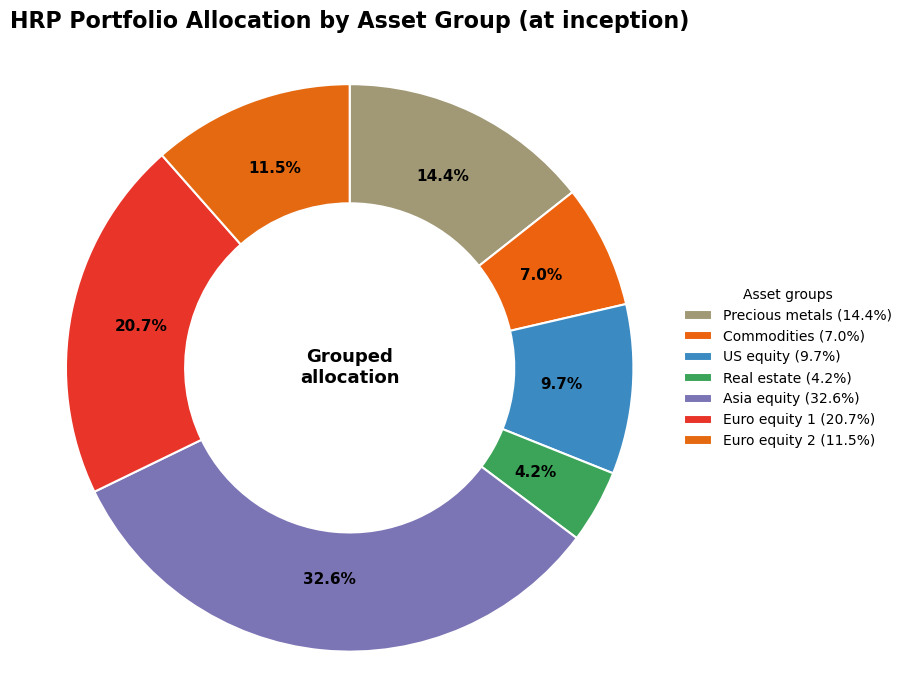

Asset / Group,Weight
Platinum,5.91%
Silver,1.42%
Gold,7.04%
Precious metals subtotal,14.37%
Crop,4.48%
WTI,2.54%
Commodities subtotal,7.02%
Nasdaq,2.77%
SP 500,3.50%
Russel 2000,3.40%


In [12]:
from matplotlib.colors import to_hex

index_hrp = list(weights[0].index)
weights_ordered = [pd.Series(weights[x], index = index_hrp) for x in range(len(weights))] #same as "weights" list, but for all nested Series the order (index) is now preserved
weights_table_ = (pd.DataFrame())._append(weights_ordered) #weights in dataframe -> index is 0:len(R) and columns are assets

w_plot = weights_table_.iloc[0].dropna().astype(float)
w_plot = w_plot[w_plot > 0]

# --------------------------------------------------
# Build grouped pie data and table data
# --------------------------------------------------
ASSET_GROUPS = {
    "Precious metals": ["Platinum", "Silver", "Gold"],
    "Commodities":     ["Crop", "WTI"],
    "US equity":       ["Nasdaq", "SP 500", "Russel 2000"],
    "Real estate":     ["US Real Estate"],
    "Asia equity":     ["Nikkei", "ASX", "MSCI Em. Mkt.", "Hang Seng"],
    "Euro equity 1":   ["FTSE 100", "DAX", "AEX", "CAC", "IBEX", "FTSE MIB"],
    "Euro equity 2":   ["SMI", "ATX"],
    "Bonds":           ["Eurozone Bonds", "US Treasury"],
}

GROUP_CMAPS = {
    "Precious metals": "cividis",
    "Commodities":     "Oranges",
    "US equity":       "Blues",
    "Real estate":     "Greens",
    "Asia equity":     "Purples",
    "Euro equity 1":   "Reds",
    "Euro equity 2":   "YlOrBr",
    "Bonds":           "Greys",
}

def get_group_color(cmap_name):
    return plt.get_cmap(cmap_name)(0.65)


def autopct_threshold(threshold=3):
    def _fmt(pct):
        return f"{pct:.1f}%" if pct >= threshold else ""
    return _fmt

# --------------------------------------------------
# Check for assets not assigned to any group
# --------------------------------------------------
asset_to_group = {
    asset: group
    for group, assets in ASSET_GROUPS.items()
    for asset in assets
}

unknown_assets = [
    asset for asset in w_plot.index
    if asset not in asset_to_group
]

if unknown_assets:
    raise ValueError(
        f"These assets are in weights_table_ but not assigned to any group: {unknown_assets}"
    )

group_labels = []
group_values = []
group_colors = []

table_rows = []
group_color_lookup = {}

for group, group_assets in ASSET_GROUPS.items():

    present_assets = [
        asset for asset in group_assets
        if asset in w_plot.index
    ]

    # Skip missing groups, e.g. Bonds if bond columns are absent
    if len(present_assets) == 0:
        continue

    group_weight = w_plot[present_assets].sum()
    group_color = get_group_color(GROUP_CMAPS[group])

    group_labels.append(group)
    group_values.append(group_weight)
    group_colors.append(group_color)

    group_color_lookup[group] = group_color

    # Individual asset rows
    for asset in present_assets:
        table_rows.append({
            "Asset / Group": asset,
            "Weight": w_plot[asset],
            "Group": group,
            "Row Type": "asset"
        })

    # Subtotal row
    table_rows.append({
        "Asset / Group": f"{group} subtotal",
        "Weight": group_weight,
        "Group": group,
        "Row Type": "subtotal"
    })

portfolio_table = pd.DataFrame(table_rows)

# Add total row
subtotal_mask = portfolio_table["Row Type"] == "subtotal"

portfolio_table.loc[len(portfolio_table)] = {
    "Asset / Group": "Total",
    "Weight": portfolio_table.loc[subtotal_mask, "Weight"].sum(),
    "Group": "Total",
    "Row Type": "total"
}

# --------------------------------------------------
# Plot one grouped donut pie
# --------------------------------------------------
plt.figure(figsize=(9, 7), facecolor="white")

wedges, _, _ = plt.pie(
    group_values,
    labels=None,
    colors=group_colors,
    startangle=90,
    counterclock=False,
    autopct=autopct_threshold(3),
    pctdistance=0.75,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=1.5),
    textprops=dict(color="black", fontsize=11, weight="semibold")
)

plt.title(
    "HRP Portfolio Allocation by Asset Group (at inception)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.text(
    0, 0,
    "Grouped\nallocation",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

legend_labels = [
    f"{label} ({value:.1%})"
    for label, value in zip(group_labels, group_values)
]

plt.legend(
    wedges,
    legend_labels,
    title="Asset groups",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    frameon=False
)

plt.axis("equal")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Display table with colors consistent with pie chart
# --------------------------------------------------

def lighten_color(rgba, alpha=0.18):
    """
    Blend a matplotlib RGBA color with white.
    Lower alpha = lighter color.
    """
    rgb = np.array(rgba[:3])
    white = np.array([1, 1, 1])
    blended = white * (1 - alpha) + rgb * alpha
    return to_hex(blended)


def style_group_rows(row):
    row_type = row["Row Type"]
    group = row["Group"]

    if row_type == "total":
        style = (
            "font-weight: bold; "
            "background-color: #e6e6e6; "
            "border-top: 2px solid #444;"
        )

    else:
        base_color = group_color_lookup[group]

        if row_type == "subtotal":
            bg_color = lighten_color(base_color, alpha=0.35)
            style = (
                f"font-weight: bold; "
                f"background-color: {bg_color}; "
                f"border-top: 1px solid #999; "
                f"border-bottom: 1px solid #999;"
            )
        else:
            bg_color = lighten_color(base_color, alpha=0.14)
            style = f"background-color: {bg_color};"

    return [style] * len(row)


display(
    portfolio_table.style
    .format({"Weight": "{:.2%}"})
    .apply(style_group_rows, axis=1)
    .hide(axis="index")
    .hide(subset=["Group", "Row Type"], axis="columns")
    .set_properties(**{
        "text-align": "left",
        "padding": "6px 12px",
    })
    .set_table_styles([
        {"selector": "th", "props": [
            ("text-align", "left"),
            ("font-weight", "bold"),
            ("font-size", "14px"),
            ("border-bottom", "2px solid #666"),
        ]},
        {"selector": "td", "props": [
            ("font-size", "13px"),
        ]},
    ])
)

Text(0.5, 1, 'Dendrogram')

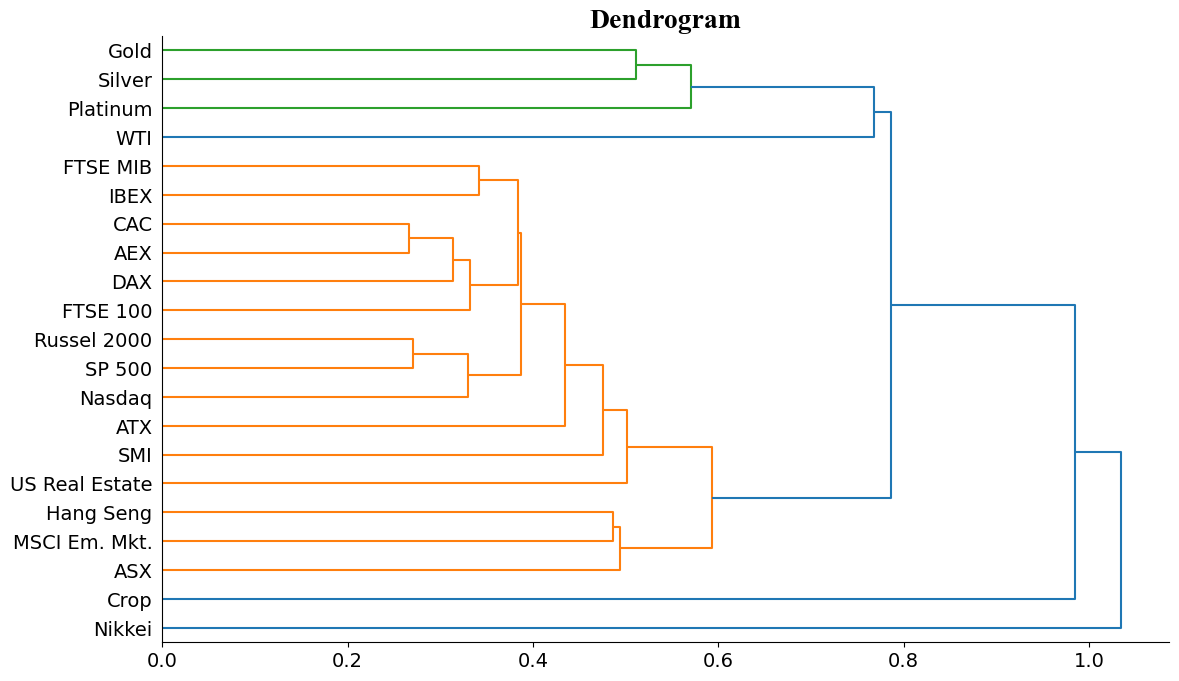

In [13]:
#------------- HRP plotting dendrogram and resorted corr matrix----------------------------
def cm_inch(cntm):
    """ 
    converts centimeters in inches
    """
    inch = cntm*0.39370
    return inch

linkage = linkk[0]
corel = correlation[0]
sorrt = sor[0]
cov = covariance[0]

font_title_dendro = {'family': 'times new roman',
        'color':  'black',
        'weight': 'bold',
        'size': 20,
        }

#DENDROGRAM
plt.figure(1,figsize = (cm_inch(33),cm_inch(20))) 
figure = plt.gca()
figure.spines['right'].set_color('none')
figure.spines['top'].set_color('none')
sch.dendrogram(linkage, labels = list(corel.index), orientation = 'right', leaf_font_size = 14) #p = 25, truncate_mode = 'level' means fixed number of nodes in graph 
plt.xticks(fontsize = 14)
plt.title('Dendrogram', fontdict = font_title_dendro, y = 1)


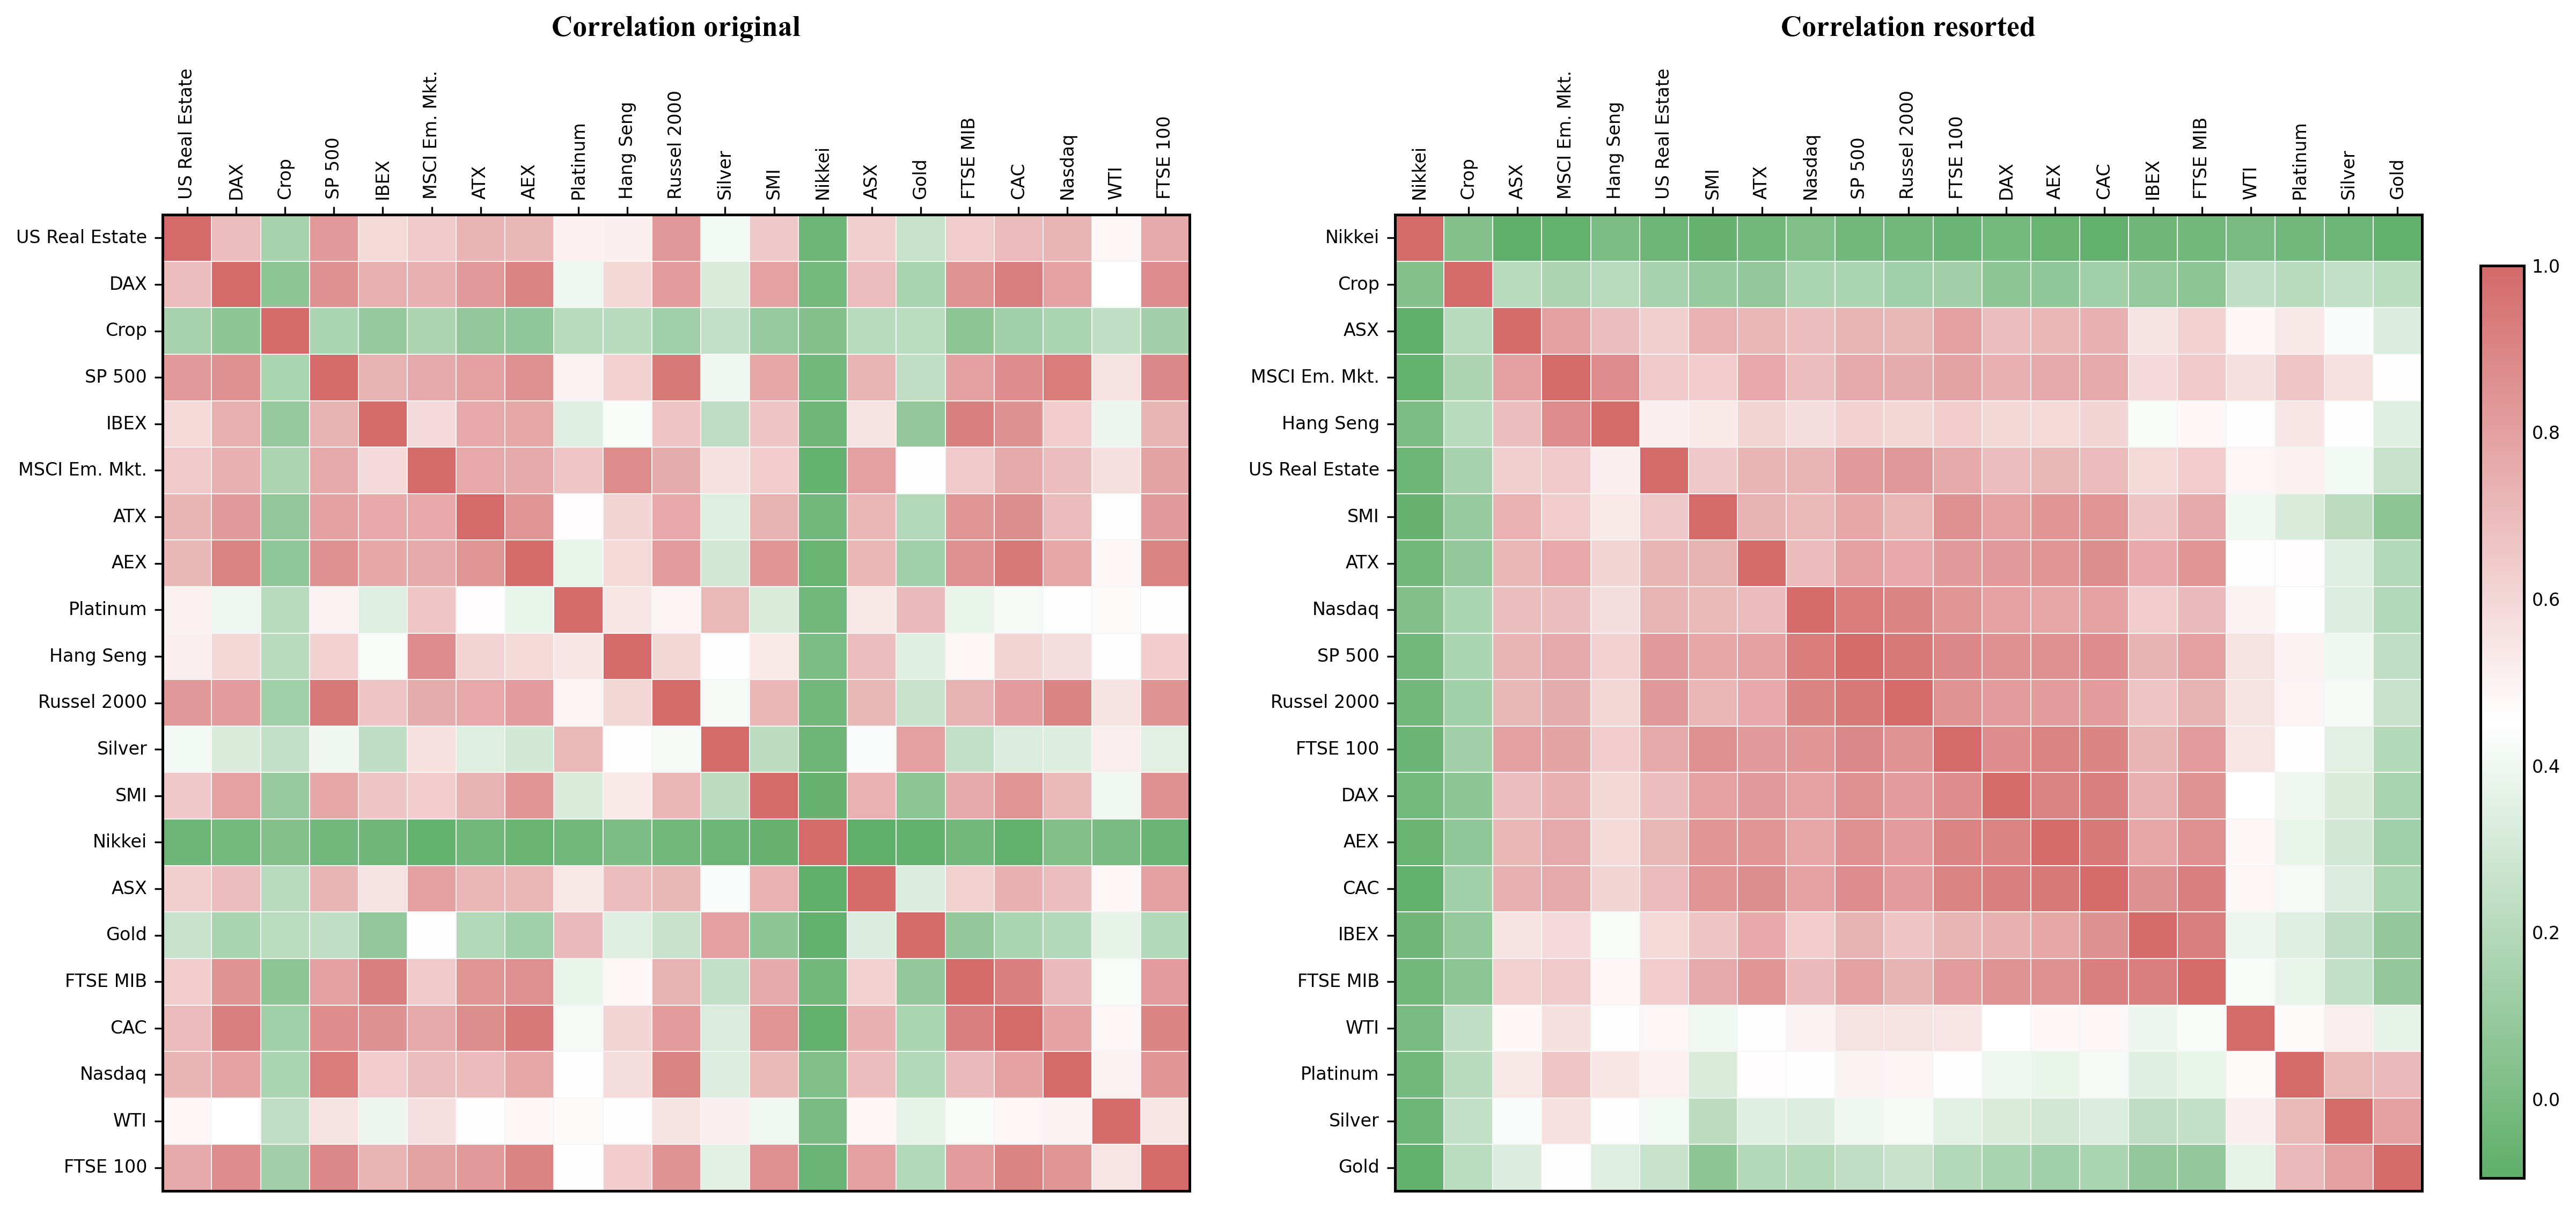

In [14]:
#CORRELATION MATRICES
import matplotlib.patches as patches
cmap = sns.blend_palette(["#5FAE6A", "#FFFFFF", "#D46A6A"], as_cmap=True, n_colors=9)

min_cor    = corel.min().min()
max_cor    = corel.max().max()
center_cor = (min_cor + max_cor) / 2

FONT_CORR  = {"family": "times new roman", "color": "black", "weight": "bold", "size": 13}
TICK_SIZE  = 8

def _style_heatmap(ax, matrix):
    """Apply shared axis styling to a correlation heatmap axes."""
    ax.yaxis.tick_left()
    ax.xaxis.tick_top()
    ax.set_xticklabels(ax.get_xmajorticklabels(), fontsize=TICK_SIZE, rotation=90)
    ax.set_yticklabels(ax.get_ymajorticklabels(), fontsize=TICK_SIZE, rotation=0)
    n_rows, n_cols = matrix.shape
    ax.add_patch(patches.Rectangle(
        (0, 0), n_cols, n_rows,
        fill=False, edgecolor="black", linewidth=1.2, clip_on=False
    ))

# ── Single figure with two side-by-side heatmaps ─────────────────────────────
fig, (ax_orig, ax_sort) = plt.subplots(
    1, 2,
    figsize=(cm_inch(46), cm_inch(20)),   # wide enough for two square matrices
    dpi=300,
    gridspec_kw={"wspace": 0.2},         # tight horizontal gap
)

# Left: original correlation
sns.heatmap(
    corel,
    vmin=min_cor, vmax=1, center=center_cor,
    cmap=cmap, linewidths=0.4, linecolor="#f5f5f5",
    annot=False, yticklabels=True, xticklabels=True,
    cbar=False,                            # no colorbar on the left panel
    ax=ax_orig,
)
_style_heatmap(ax_orig, corel)
ax_orig.set_title("Correlation original", fontdict=FONT_CORR, pad=80)

# Right: resorted correlation — shared colorbar drawn here
corel_sorted = corel.loc[sorrt, sorrt]
hm = sns.heatmap(
    corel_sorted,
    vmin=min_cor, vmax=1, center=center_cor,
    cmap=cmap, linewidths=0.4, linecolor="#f5f5f5",
    annot=False, yticklabels=True, xticklabels=True,
    cbar=True,                             # single colorbar on the right panel
    cbar_ax=fig.add_axes([0.92, 0.12, 0.015, 0.72]),  # [left, bottom, width, height]
    ax=ax_sort,
)
_style_heatmap(ax_sort, corel_sorted)
ax_sort.set_title("Correlation resorted", fontdict=FONT_CORR, pad=80)

# ── Colorbar styling ──────────────────────────────────────────────────────────
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=TICK_SIZE, colors="black", length=0)
cbar.outline.set_visible(True)
cbar.outline.set_edgecolor("black")
cbar.outline.set_linewidth(1.2)
plt.show()

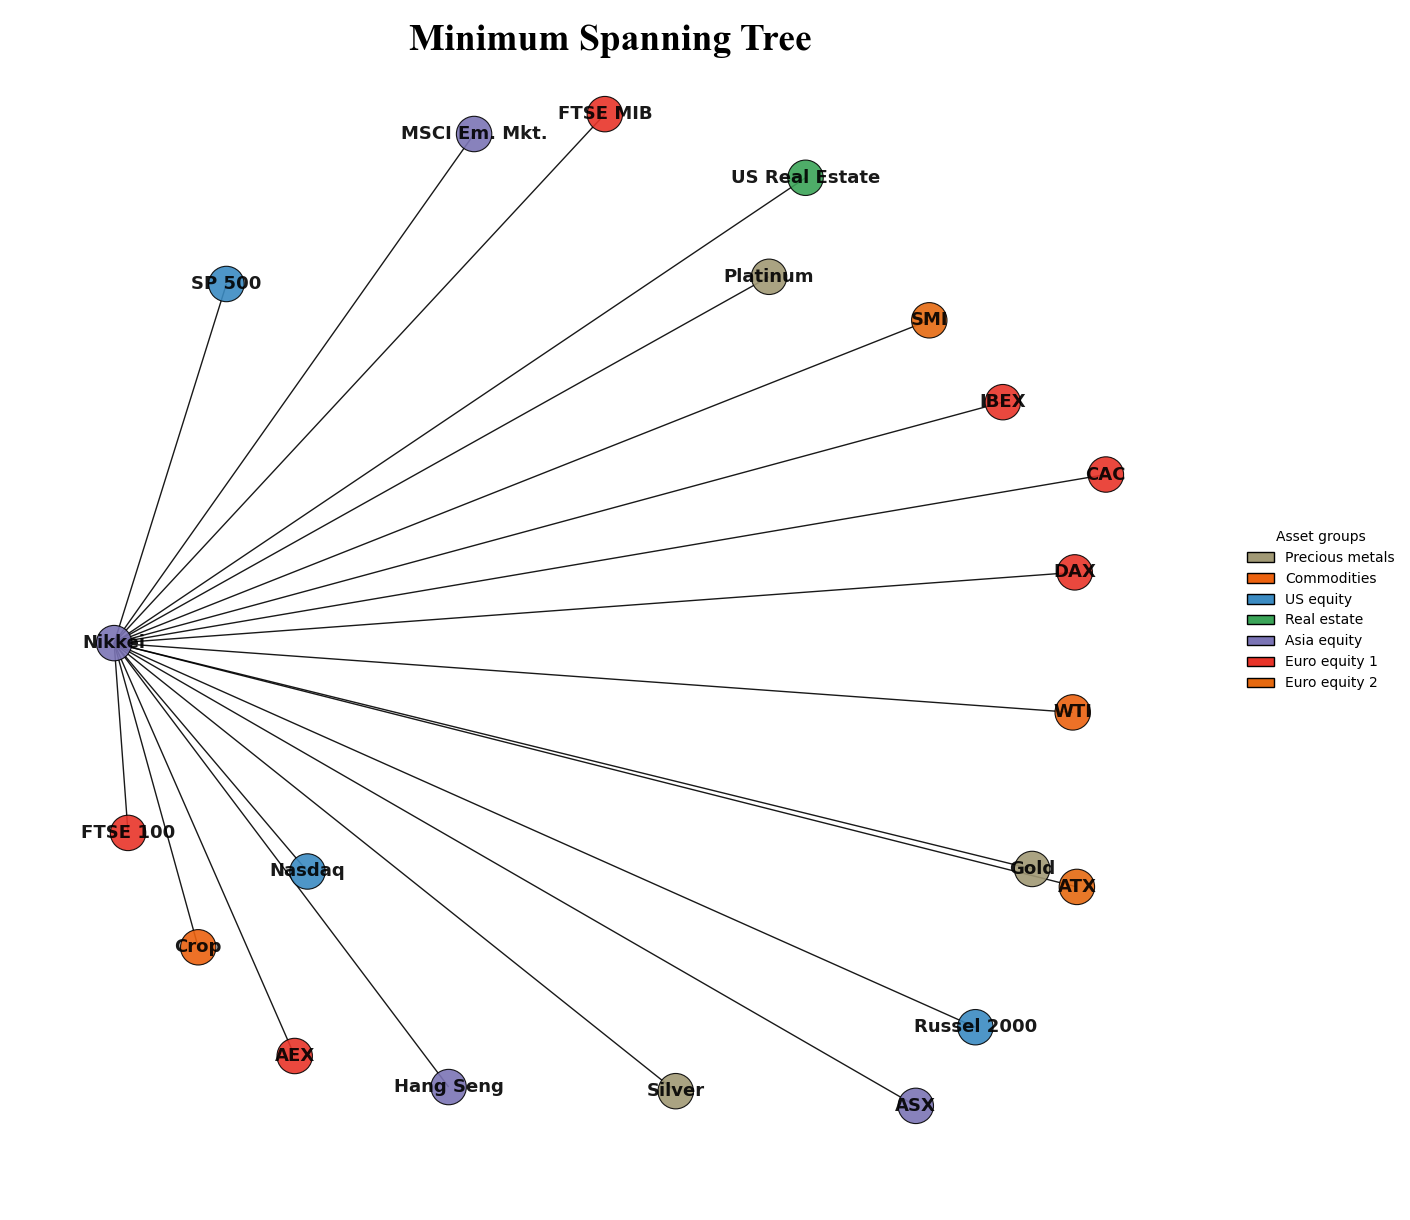

In [15]:
#MINIMUM SPANNING TREE
from matplotlib.patches import Patch
group_color_lookup = {
    group: get_group_color(cmap)
    for group, cmap in GROUP_CMAPS.items()
}

font_title_MST = {'family': 'times new roman',
        'color':  'black',
        'weight': 'bold',
        'size': 27,
        }

stocks = list(corel.index.values)

# Check that every stock has a group
unknown_assets = [
    asset for asset in stocks
    if asset not in asset_to_group
]

if unknown_assets:
    raise ValueError(
        f"These assets are in corel but not assigned to any group: {unknown_assets}"
    )

cor_matrix = corel.to_numpy()

G = nx.from_numpy_array(cor_matrix)
G = nx.relabel_nodes(G, dict(enumerate(stocks)))

Z = nx.minimum_spanning_tree(G, algorithm='kruskal')

# Node colors according to asset group
node_colors = [
    group_color_lookup[asset_to_group[node]]
    for node in Z.nodes()
]

# --------------------------------------------------
# Plot MST
# --------------------------------------------------
plt.figure(20, figsize=(12, 12), facecolor="white")

pos = nx.spring_layout(Z, seed=42)

nx.draw(
    Z,
    pos=pos,
    with_labels=True,
    nodelist=list(Z.nodes()),
    node_color=node_colors,
    node_size=650,
    font_size=13,
    font_weight="bold",
    linewidths=0.8,
    edgecolors="black",
    alpha=0.9
)

plt.title(
    'Minimum Spanning Tree',
    fontdict=font_title_MST,
    y=0.96
)

# Legend using same group colors
legend_handles = [
    Patch(
        facecolor=group_color_lookup[group],
        edgecolor="black",
        label=group
    )
    for group in ASSET_GROUPS.keys()
    if any(asset in stocks for asset in ASSET_GROUPS[group])
]

plt.legend(
    handles=legend_handles,
    title="Asset groups",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.show()

# HRP Portfolio - out of sample performance


In [16]:
# ── HRP Out-of-sample performance ─────────────────────────────────────────────────
# For each rebalance window: apply optimised weights to realised asset returns.

performance_per_window = []

for x in reb_index:
    weights_ = weights[x]
    data = table_perform[x].drop("Dates", axis=1)[sor[x]]  # 'sor[x]' reorders columns to match the clustering order used during optimisation.
    yld = np.matmul(weights_.T, data.T)                       
    performance_per_window.append(yld)

performance = [ret for window in performance_per_window for ret in window]
performance.insert(0, 0)

# ── Cumulative chart (base = 100) ─────────────────────────────────────────────
chart = [100]
for ret in performance[1:]:
    chart.append(chart[-1] * (1 + ret))

# ── Return metrics ────────────────────────────────────────────────────────────
n_years = len(performance) / 52

# Total and annualised return from the compounded chart
return_total  = chart[-1] / chart[0]
return_annual = return_total ** (1 / n_years) - 1
# Note: relatively low return is expected given bond-heavy composition

# Arithmetic annualised return (mean weekly return × 52).
# Slightly different from geometric return_annual above — this is expected:
# arithmetic mean > geometric mean whenever returns have any variance (Jensen's inequality).
return_annual_arithmetic = np.mean(performance) * 52

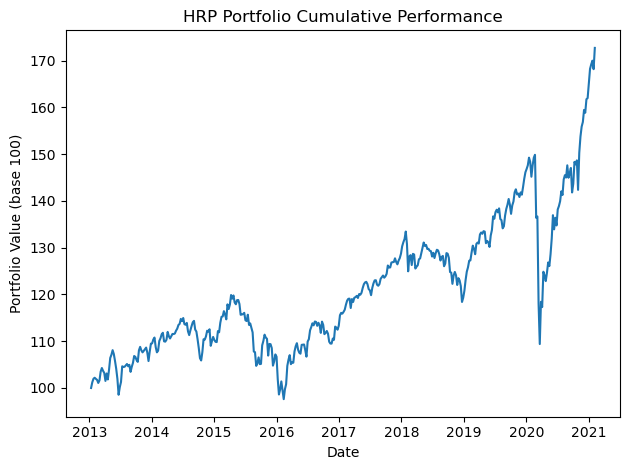

In [17]:
# ── Plot ──────────────────────────────────────────────────────────────────────
dates = pd.to_datetime(table["Dates"]).loc[T:]   # date index for the out-of-sample period only

plt.figure(4)
plt.plot(dates, chart)
plt.title("HRP Portfolio Cumulative Performance")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (base 100)")
plt.tight_layout()
plt.show()

# HRP Portfolio - transaction costs


In [18]:
#------------- HRP transaction costs - Part 1, adjust data----------------------------

index_rebalance = list(range(T,len(table),rebalance))
dates_rebalance = dates.loc[index_rebalance]

prices = (pd.read_excel(path, sheet_name="Prices")
            .drop("Dates", axis=1)
            .iloc[1:]
            .pipe(lambda df: df.set_index(pd.RangeIndex(len(table)))))

# Extract prices at rebalance dates only, aligned to HRP asset order
prices_rebalance = (prices
    .loc[index_rebalance]
    .reindex(columns=index_hrp)
    .reset_index(drop=True))

# ── Portfolio wealth at each rebalance date ───────────────────────────────────
# Compound initial wealth (Wlt) through the full out-of-sample weekly return series.
# Then slice only the rebalance rows to get portfolio value just AFTER each rebalance.

w, wealth_values = Wlt, []
for ret in performance:
    w *= (1 + ret)
    wealth_values.append(w)

wealth = pd.Series(wealth_values, index=range(T, len(table)))
wealth_rebalance = wealth.loc[index_rebalance].reset_index(drop=True)

# ── Asset-level values at each rebalance (AFTER rebalance) ───────────────────
# For each rebalance period x: multiply the asset weights by total portfolio wealth
# to get the monetary value allocated to each asset.
value_assets_rebalance_table = pd.DataFrame(
    [weights_table_.iloc[x] * wealth_rebalance[x]
     for x in range(len(index_rebalance))],
    columns=index_hrp
)

quantity = value_assets_rebalance_table / prices_rebalance

In [19]:
#------------- HRP transaction costs - Part 2, define transaction costs----------------------------#
# Cost model:
#   c1 — applied to assets fully entering or exiting the portfolio
#        (i.e. weight moves from 0 to nonzero or nonzero to 0)
#   c2 — applied to assets already held whose weight merely shifts
#        (continuous rebalancing cost, typically c2 < c1)
#
# Inception (x=0): treated as a full buy-in, so the entire portfolio value is charged at c1

costs_inception = value_assets_rebalance_table.iloc[0].sum() * c1

# ── Absolute weight changes between consecutive rebalances ────────────────────
# diff() gives w[x] - w[x-1] for each row; iloc[1:] drops the NaN first row.
# Taking abs() gives the turnover magnitude per asset per rebalance.
abs_diff = weights_table_.diff().iloc[1:].abs()
abs_diff.index = range(len(abs_diff))   # reset to 0-based so .loc[x] is unambiguous

# ── Per-rebalance cost calculation ────────────────────────────────────────────
costs = [costs_inception]   # x=0 handled above; loop starts at x=1

for x in range(1, len(weights_table_)):
    w_cur  = weights_table_.iloc[x]
    w_prev = weights_table_.iloc[x - 1]

    # Assets exiting: weight is now exactly 0
    asset_out = list(w_cur[w_cur == 0].index)

    # Assets entering: weight was 0 last period, so the full new weight
    # equals the change (w_cur - w_prev == w_cur  ↔  w_prev == 0)
    asset_in  = list(w_cur[(w_cur - w_prev) == w_cur].index)

    in_out = asset_in + asset_out   # all assets crossing the zero boundary

    row = abs_diff.loc[x - 1]

    # c1 cost: turnover on entering/exiting assets × portfolio value
    cost_entry_exit  = row[in_out].sum()      * wealth_rebalance.iloc[x] * c1

    # c2 cost: turnover on continuously-held assets × portfolio value
    cost_rebalance   = row.drop(in_out).sum() * wealth_rebalance.iloc[x] * c2

    costs.append(cost_entry_exit + cost_rebalance)
    

In [20]:
#------------- HRP transaction costs - Part 3 , prepare data for plots ----------------------------

costs_ = pd.Series(costs, index=range(0, B, rebalance))
costs_full = pd.Series(np.zeros(B)).add(costs_).fillna(0)

# ── Net-of-cost cumulative chart ──────────────────────────────────────────────
# Each week: grow portfolio by that week's return, then subtract the rebalance
# cost (0 on non-rebalance weeks). Starting value is the initial wealth Wlt - inception cost.
chart_tc = [Wlt - costs_full[0]]
for ret, cost in zip(performance[1:], costs_full[1:]):
    chart_tc.append(chart_tc[-1] * (1 + ret) - cost)


n_years = len(performance) / 52
return_total_tc  = chart_tc[-1] / Wlt
return_annual_tc = return_total_tc ** (1 / n_years) - 1

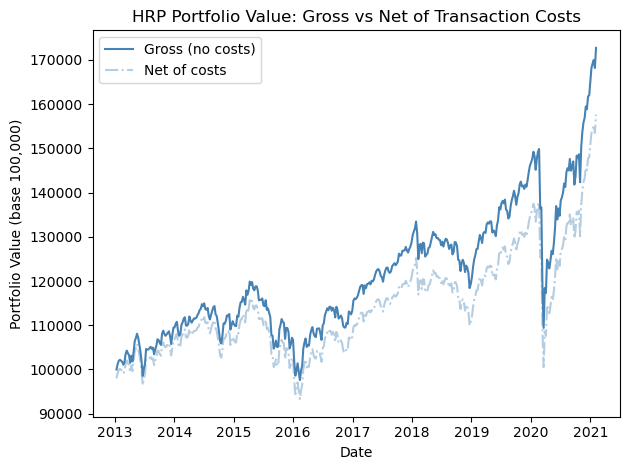

In [21]:
# Figure: gross wealth vs net-of-cost wealth
fig6, ax6 = plt.subplots(num=6)
ax6.plot(dates, wealth,    label="Gross (no costs)",  color="steelblue")
ax6.plot(dates, chart_tc,  label="Net of costs",      color="steelblue",
         linestyle="dashdot", alpha=0.4)
ax6.set_title("HRP Portfolio Value: Gross vs Net of Transaction Costs")
ax6.set_xlabel("Date")
ax6.set_ylabel(f"Portfolio Value (base {Wlt:,.0f})")
ax6.legend()
plt.tight_layout()
plt.show()


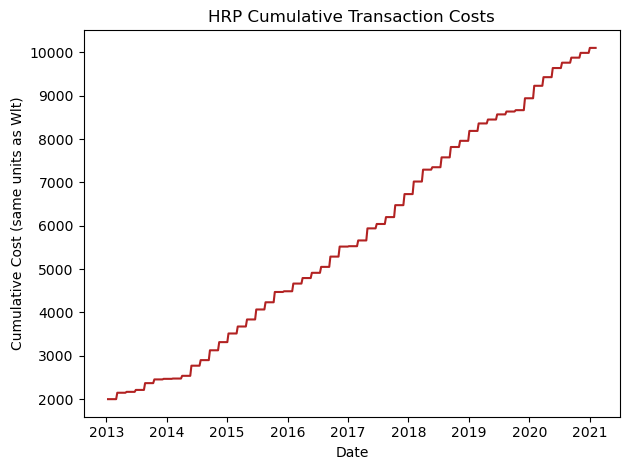

In [22]:
# Figure: cumulative transaction costs over time
fig7, ax7 = plt.subplots(num=7)
ax7.plot(dates, costs_full.cumsum(), color="firebrick")
ax7.set_title("HRP Cumulative Transaction Costs")
ax7.set_xlabel("Date")
ax7.set_ylabel("Cumulative Cost (same units as Wlt)")
plt.tight_layout()
plt.show()


# HRP, 1/N, MGV and Sharpe portfolios


In [23]:
#------------- 1/N STRATEGY----------------------------
chart_1N = Strategy_1N(path, Years_optimization, rebalance, include_bonds, index_hrp)

#------------- MGV_SHARP----------------------------
chart_MGV, chart_Sharp, weights_table_MGV, weights_table_Sharp, costs__MGV, costs__Sharp, covariance_MGV_fromoptim = MGV_Sharpe(path, Years_optimization, rebalance, include_bonds, Wlt, index_hrp, c1, c2)

Text(0.5, 0.95, 'Portfolio performance')

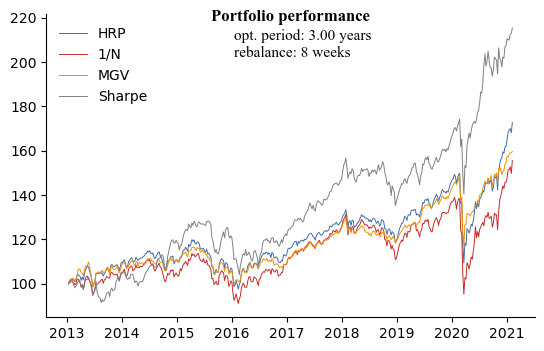

In [24]:
#chart all strategies
font_title = {'family': 'times new roman',
        'color':  'black',
        'weight': 'bold',
        'size': 12,
        }

plt.figure(9, figsize=(cm_inch(16),cm_inch(10))) 
figure = plt.gca()
figure.spines['right'].set_color('none')
figure.spines['top'].set_color('none')
plt.plot(dates,chart, label = 'HRP', color = '#416DA9', lw = 0.7) #blu
plt.plot(dates,chart_1N, label = '1/N',color = '#C92828', lw = 0.7) #rosso 
plt.plot(dates,chart_MGV, label = 'MGV', color = '#F39100',lw = 0.7) #arancio
plt.plot(dates,chart_Sharp, label = 'Sharpe',color = '#7D8081', lw = 0.7) #grigio
plt.legend(frameon=False)
plt.text(x=0.385, y = 0.86, s=f'opt. period: {Years_optimization:.2f} years \nrebalance: {rebalance} weeks', fontdict = {'family': 'times new roman',
        'color':  'black',
        'weight': 'normal',
        'size': 11,
        }, transform=figure.transAxes)
plt.title('Portfolio performance', fontdict = font_title, y = 0.95)

Text(0.5, 0.96, 'Portfolio at inception')

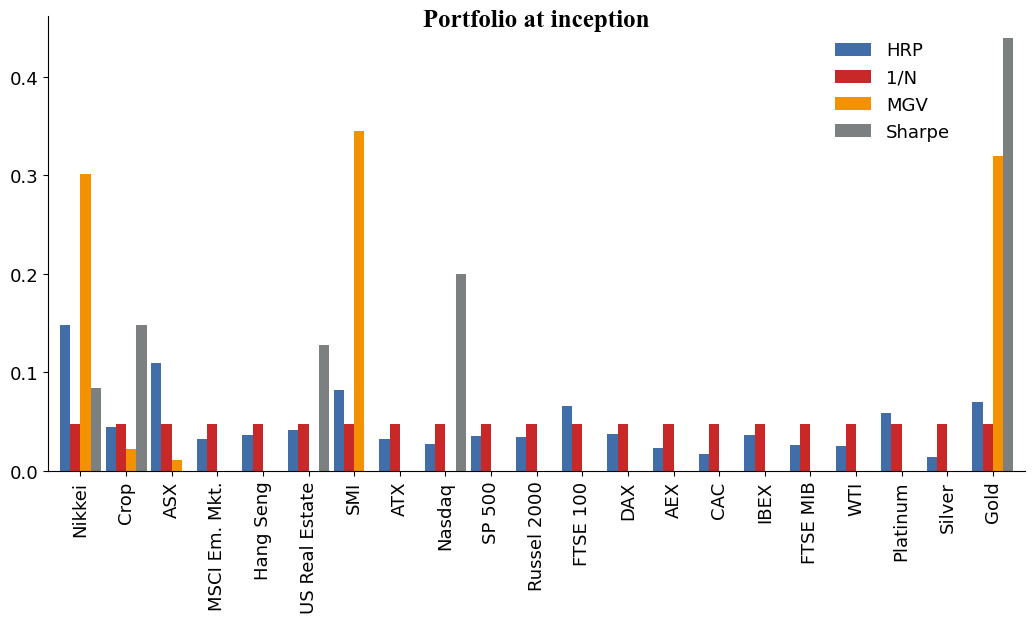

In [25]:
#weights graph at inception
n_assets = len(index_hrp)

weights_0 = pd.DataFrame({
    "HRP":    weights_table_.iloc[0],
    "1/N":    1 / n_assets,              
    "MGV":    weights_table_MGV.iloc[0],
    "Sharpe": weights_table_Sharp.iloc[0],
}, index=index_hrp)


font_title_bar = {'family': 'times new roman',
        'color':  'black',
        'weight': 'bold',
        'size': 18,
        }
weights_0.plot.bar(color={
        "HRP": "#416DA9",
        "1/N": "#C92828",
        "MGV": "#F39100",
        "Sharpe": "#7D8081"}, width = 0.90, fontsize = 13, figsize=(cm_inch(32),cm_inch(15))) #subplots = True   #C92828': '1/N'
figure = plt.gca()
figure.spines['right'].set_color('none')
figure.spines['top'].set_color('none') 
plt.legend(frameon=False, fontsize = 13, bbox_to_anchor=(0.94, 0.98))
plt.title('Portfolio at inception', fontdict = font_title_bar, y = 0.96)


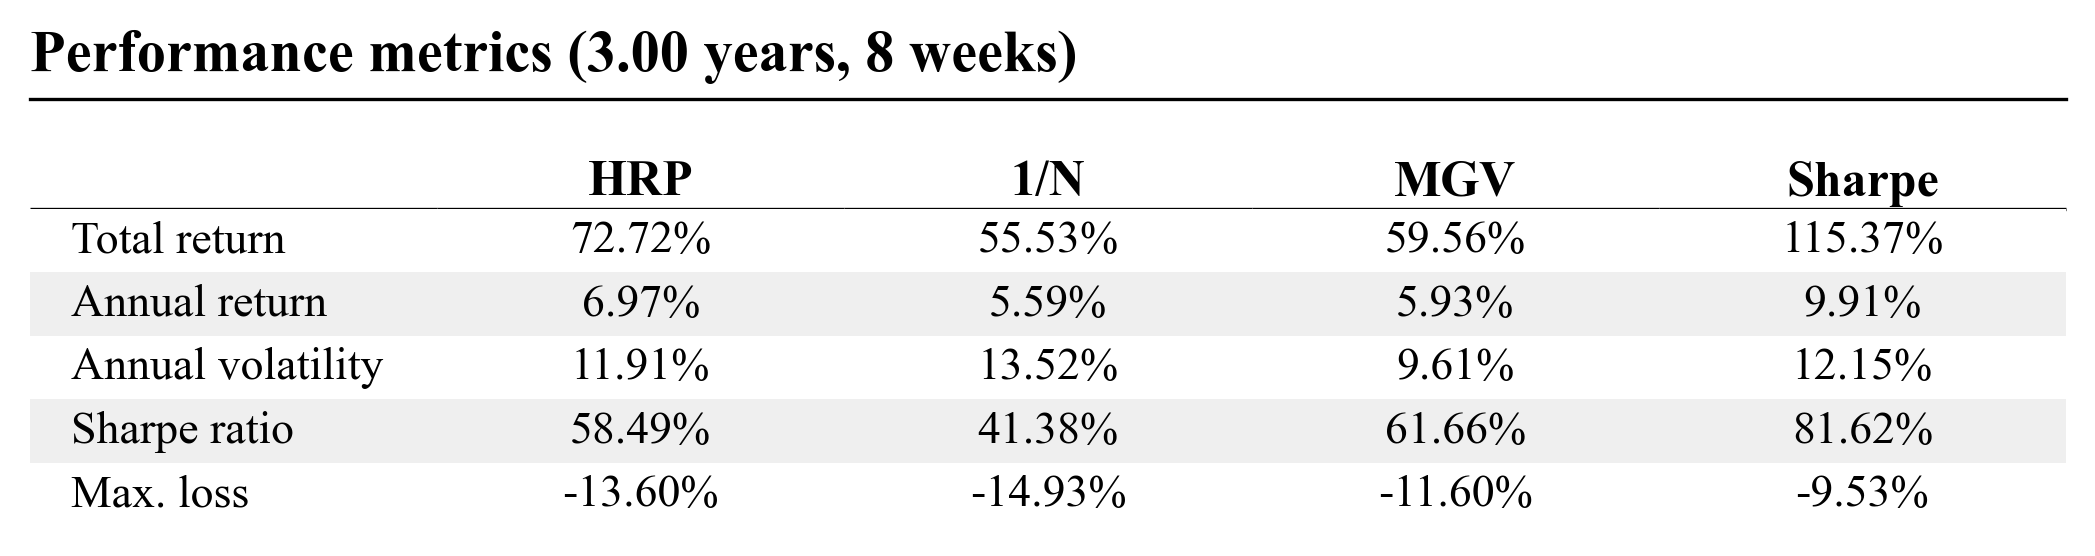

In [26]:
#performance metrics. 
n_years = len(performance) / 52

def _metrics(chart: list, weekly_returns: pd.Series, label: str) -> dict:
    """
    Compute total return, annualised return, annualised volatility,
    Sharpe ratio, and worst weekly return for a single strategy.

    Args:
        chart:          Cumulative value series (base 100).
        weekly_returns: Weekly return series (same length as chart).
        label:          Strategy name, used only for reference.
    """
    total_ret   = chart[-1] / chart[0] - 1
    annual_ret  = (1 + total_ret) ** (1 / n_years) - 1
    annual_vol  = weekly_returns.std() * (52 ** 0.5)
    sharpe      = annual_ret / annual_vol          # risk-free = 0
    max_loss    = weekly_returns.min()

    return {
        "Total return":    total_ret,
        "Annual return":    annual_ret,
        "Annual volatility":         annual_vol,
        "Sharpe ratio":      sharpe,
        "Max. loss":   max_loss,
    }

# ── Weekly return series ──────────────────────────────────────────────────────
def _weekly_rets(chart: list) -> pd.Series:
    s = pd.Series(chart).pct_change()
    s.iloc[0] = 0
    return s

rets_HRP    = pd.Series(performance)        
rets_1N     = _weekly_rets(chart_1N)
rets_MGV    = _weekly_rets(chart_MGV)
rets_Sharpe = _weekly_rets(chart_Sharp)

# ── In-sample annualised volatility (first optimisation window) ───────────────

cov_0 = covariance[0].reindex(index=index_hrp, columns=index_hrp)

def _insample_vol(weights: pd.Series) -> float:
    return (weights @ cov_0 @ weights * 52) ** 0.5

insample_vol = {
    "HRP":    _insample_vol(weights_0["HRP"]),
    "MGV":    _insample_vol(weights_0["MGV"]),
    "Sharpe": _insample_vol(weights_0["Sharpe"]),
    "1/N":    _insample_vol(weights_0["1/N"]),
}

# ── Build summary metrics table ───────────────────────────────────────────────
strategies = {
    "HRP":    (chart,       rets_HRP),
    "1/N":    (chart_1N,    rets_1N),
    "MGV":    (chart_MGV,   rets_MGV),
    "Sharpe": (chart_Sharp, rets_Sharpe),
}

metrics = pd.DataFrame(
    {label: _metrics(ch, rets, label) for label, (ch, rets) in strategies.items()}
)

#plot metrics table
fig_tbl, ax_tbl = plt.subplots(figsize=(cm_inch(18), cm_inch(5)), dpi=300)
ax_tbl.axis("off")

# --------------------------------------------------
# Title
# --------------------------------------------------
ax_tbl.text(
    0.00, 1.08,
    f'Performance metrics ({Years_optimization:.2f} years, {rebalance} weeks)',
    transform=ax_tbl.transAxes,
    fontsize=14,
    fontweight="bold",
    family="Times New Roman",
    va="bottom",
    ha="left"
)

# horizontal line under title
ax_tbl.plot(
    [0, 1], [1.04, 1.04],
    transform=ax_tbl.transAxes,
    color="black",
    linewidth=0.8,
    clip_on=False
)

# --------------------------------------------------
# Build table text
# --------------------------------------------------
cell_text = []

for metric_name, row in metrics.iterrows():
    formatted_row = [metric_name] + [f"{v:.2%}" for v in row]
    cell_text.append(formatted_row)

col_labels = [""] + metrics.columns.tolist()

# --------------------------------------------------
# Create table
# --------------------------------------------------
tbl = ax_tbl.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
    colLoc="center",
    bbox=[0.00, 0.00, 1.00, 0.90]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.0, 1.45)

# --------------------------------------------------
# Style table
# --------------------------------------------------
n_rows = len(cell_text)
n_cols = len(col_labels)

for (row, col), cell in tbl.get_celld().items():

    # Remove all borders by default
    cell.set_edgecolor("white")
    cell.set_linewidth(0)

    # Font
    cell.get_text().set_fontfamily("Times New Roman")

    # Header row
    if row == 0:
        cell.set_text_props(
            fontweight="bold",
            fontsize=12,
            color="black"
        )
        cell.set_facecolor("white")
        cell.set_height(0.13)

    # Body rows
    else:
        cell.set_text_props(
            fontsize=11,
            color="black"
        )

        # alternating row shading
        if row % 2 == 0:
            cell.set_facecolor("#EFEFEF")
        else:
            cell.set_facecolor("white")

        # left-align metric names
        if col == 0:
            cell.set_text_props(ha="left")

# --------------------------------------------------
# Add bottom line under header
# --------------------------------------------------
for col in range(n_cols):
    header_cell = tbl[(0, col)]
    header_cell.visible_edges = "B"
    header_cell.set_edgecolor("black")
    header_cell.set_linewidth(0.8)

plt.tight_layout()
plt.show()


Text(0.5, 0.95, 'Cumulative transaction costs')

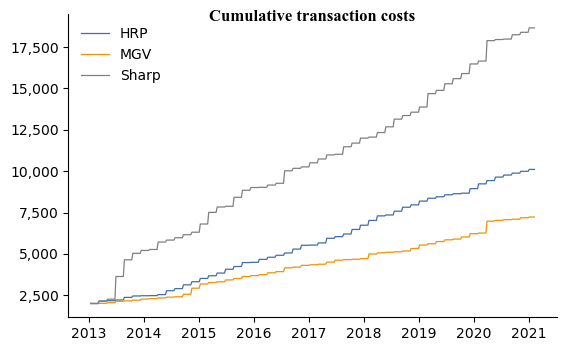

In [27]:
#------- transaction costs all strategies. 
plt.figure(11, figsize=(cm_inch(16),cm_inch(10))) #trans.costs cumulatiave all strategies
figure = plt.gca()
figure.spines['right'].set_color('none')
figure.spines['top'].set_color('none')
plt.plot(dates,costs_full.cumsum(),label = 'HRP', color = '#416DA9', lw = 0.9)   #ERROR. 53 lines. this is correct
plt.plot(dates,costs__MGV.cumsum(),label = 'MGV', color = '#F39100',lw = 0.9)      #ERROR. 422 lines
plt.plot(dates,costs__Sharp.cumsum(),label = 'Sharp',color = '#7D8081', lw = 0.9)   #ERROR. 422 lines
plt.legend(frameon=False)
figure.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.title('Cumulative transaction costs', fontdict = {'family': 'times new roman',
        'color':  'black',
        'weight': 'bold',
        'size': 12,
        }, y = 0.95)

Text(0.385, 0.86, 'opt. period: 3.00 years \nrebalance: 8 weeks')

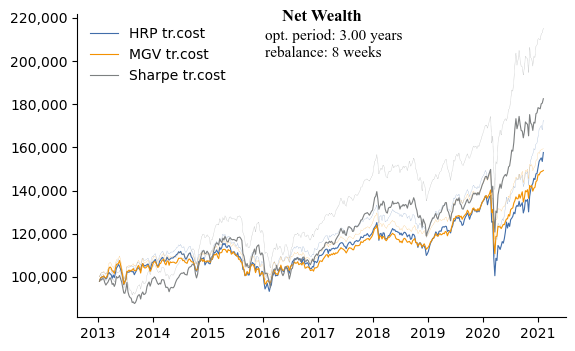

In [28]:
#wealth and tc costs for other strategies
def _net_of_cost_chart(weekly_rets: pd.Series, costs_full: pd.Series) -> list:
    chart_tc = [Wlt - costs_full.iloc[0]]
    for ret, cost in zip(weekly_rets.iloc[1:], costs_full.iloc[1:]):
        chart_tc.append(chart_tc[-1] * (1 + ret) - cost)
    return chart_tc

def _gross_wealth(weekly_rets: pd.Series) -> pd.Series:
    wealth = [Wlt]
    for ret in weekly_rets.iloc[1:]:
        wealth.append(wealth[-1] * (1 + ret))
    return pd.Series(wealth)

chart_tc_MGV    = _net_of_cost_chart(rets_MGV,    costs__MGV)
chart_tc_Sharpe = _net_of_cost_chart(rets_Sharpe, costs__Sharp)

wealth_MGV    = _gross_wealth(rets_MGV)
wealth_Sharpe = _gross_wealth(rets_Sharpe)


plt.figure(12, figsize=(cm_inch(16),cm_inch(10))) #weatlth trans. costs
figure = plt.gca()
figure.spines['right'].set_color('none')
figure.spines['top'].set_color('none')
ax = plt.plot(dates,wealth, color = '#416DA9', lw = 0.3, linestyle = 'dotted')
plt.plot(dates,chart_tc, label = 'HRP tr.cost', color = '#416DA9', lw = 0.8) #fare colore blu più sbiadito e tratteggiato
plt.plot(dates,wealth_MGV, color = '#F39100', lw = 0.3, linestyle = 'dotted')
plt.plot(dates,chart_tc_MGV, label = 'MGV tr.cost', color = '#F39100', lw = 0.8) #fare colore blu più sbiadito e tratteggiato
plt.plot(dates,wealth_Sharpe, color = '#7D8081', lw = 0.3, linestyle = 'dotted')
plt.plot(dates,chart_tc_Sharpe, label = 'Sharpe tr.cost', color = '#7D8081', lw = 0.8) #fare colore blu più sbiadito e tratteggiato
plt.legend(frameon=False)
figure.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.title('Net Wealth', fontdict = font_title, y = 0.95)
plt.text(x=0.385, y = 0.86, s=f'opt. period: {Years_optimization:.2f} years \nrebalance: {rebalance} weeks', fontdict = {'family': 'times new roman',
        'color':  'black',
        'weight': 'normal',
        'size': 11,
        }, transform=figure.transAxes)

In [29]:
#------------------grouping weights-------------
def _group_weights(weight_table: pd.DataFrame) -> pd.DataFrame:
    """
    Sum asset weights within each group, skipping assets not present in
    weight_table (e.g. bonds excluded from a particular run).
    Groups where NO asset is present are dropped entirely from the output.
    """
    result = {}
    for group, assets in ASSET_GROUPS.items():
        available = [a for a in assets if a in weight_table.columns]
        if available:                                    # skip empty groups
            result[group] = weight_table[available].sum(axis=1)
    return pd.DataFrame(result)

STRATEGY_WEIGHTS = {
    "HRP":    weights_table_,
    "MGV":    weights_table_MGV,
    "Sharpe": weights_table_Sharp,
}

grouped_weights = {
    strategy: _group_weights(weight_table)
    for strategy, weight_table in STRATEGY_WEIGHTS.items()
}



FONT = {"family": "Times New Roman", "color": "black", "weight": "bold", "size": 12}
ANNOTATION_FONT = {**FONT, "weight": "normal", "size": 10}

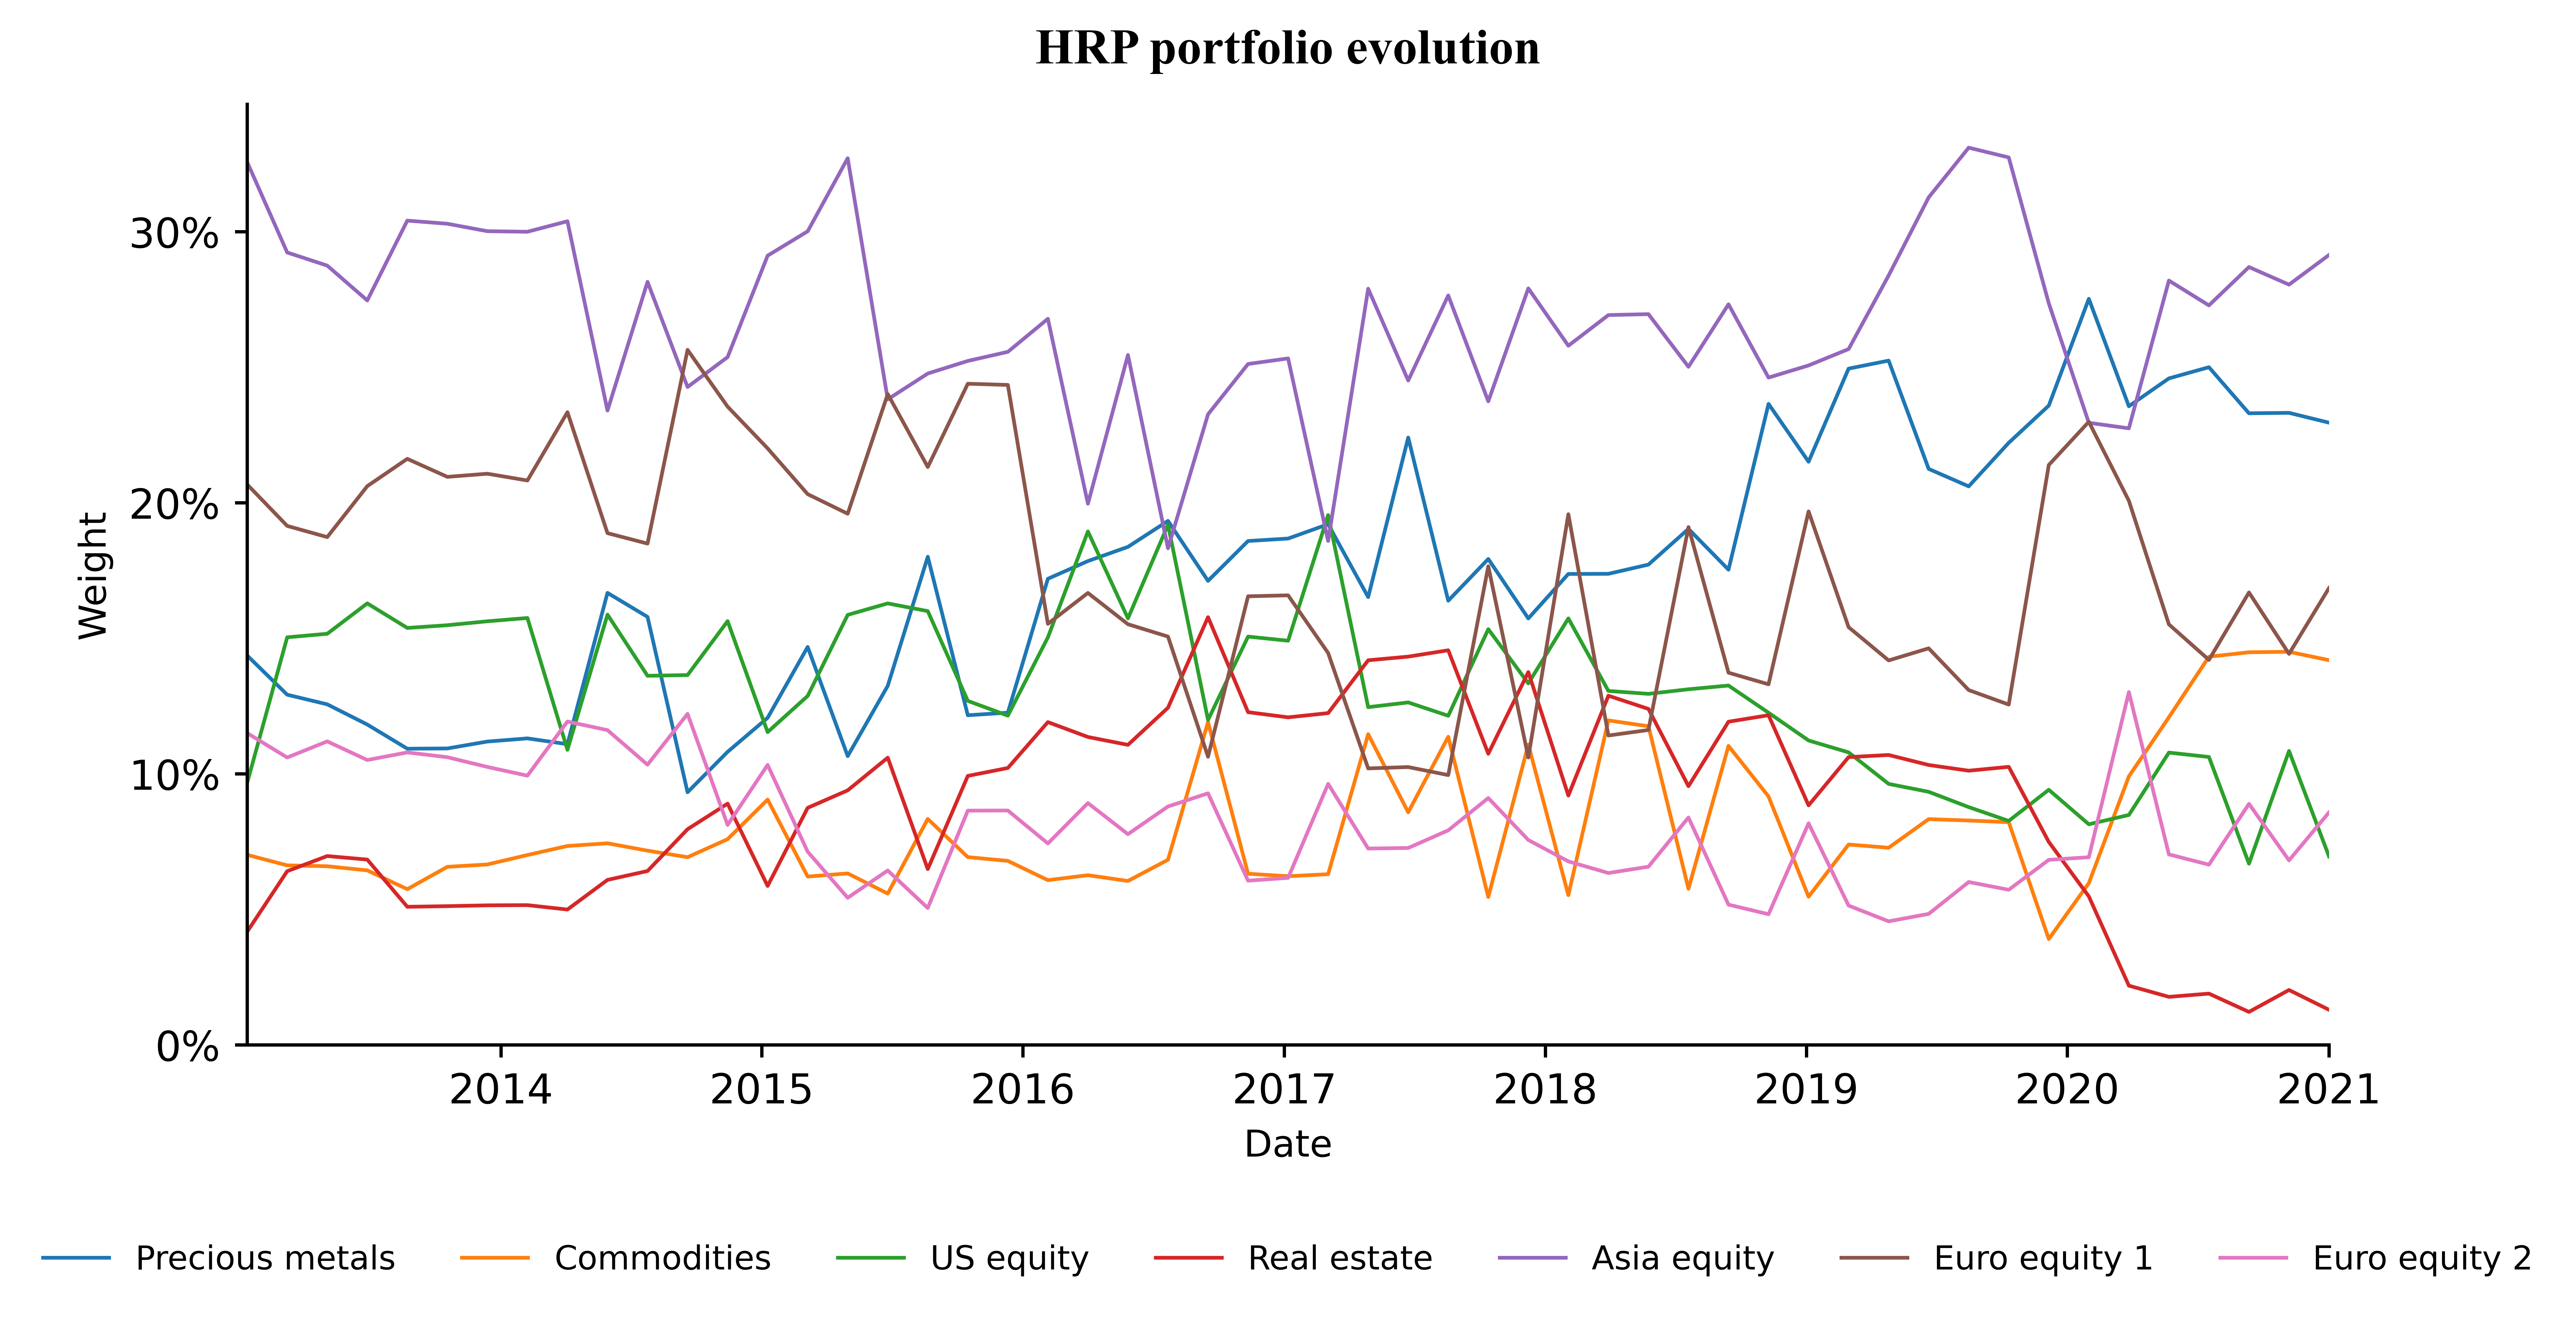

In [30]:
# ────────────────────────────────── HRP grouped weights over time ──────────────────────────────────
fig, ax = plt.subplots(num=13, dpi=900, figsize=(cm_inch(20), cm_inch(12)))

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(colors="#666666", length=3)

# Plot only groups present in this run (bonds column absent if not in analysis)
for group, series in grouped_weights["HRP"].items():
    ax.plot(dates_rebalance, series, label=group, lw=0.9)

ax.set_title("HRP portfolio evolution", fontdict=FONT, loc="center", pad=10)
ax.set_xlabel("Date", fontsize=9, color="#666666")
ax.set_ylabel("Weight", fontsize=9, color="#666666")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.tick_params(colors="black", length=3)
ax.set_xlabel("Date", fontsize=9, color="black")
ax.set_ylabel("Weight", fontsize=9, color="black")

ax.xaxis.label.set_color("black")
ax.yaxis.label.set_color("black")
plt.setp(ax.get_xticklabels(), color="black")
plt.setp(ax.get_yticklabels(), color="black")

ax.legend(
    frameon=False,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),   # below the x-axis label
    ncol=len(grouped_weights["HRP"].columns),
)

ax.set_xlim(dates_rebalance.iloc[0], dates_rebalance.iloc[-1])
ax.set_ylim(bottom=0)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.10))

plt.tight_layout()
plt.subplots_adjust(bottom=0.25, left=0.08, right=0.97, top=0.92)
plt.show()

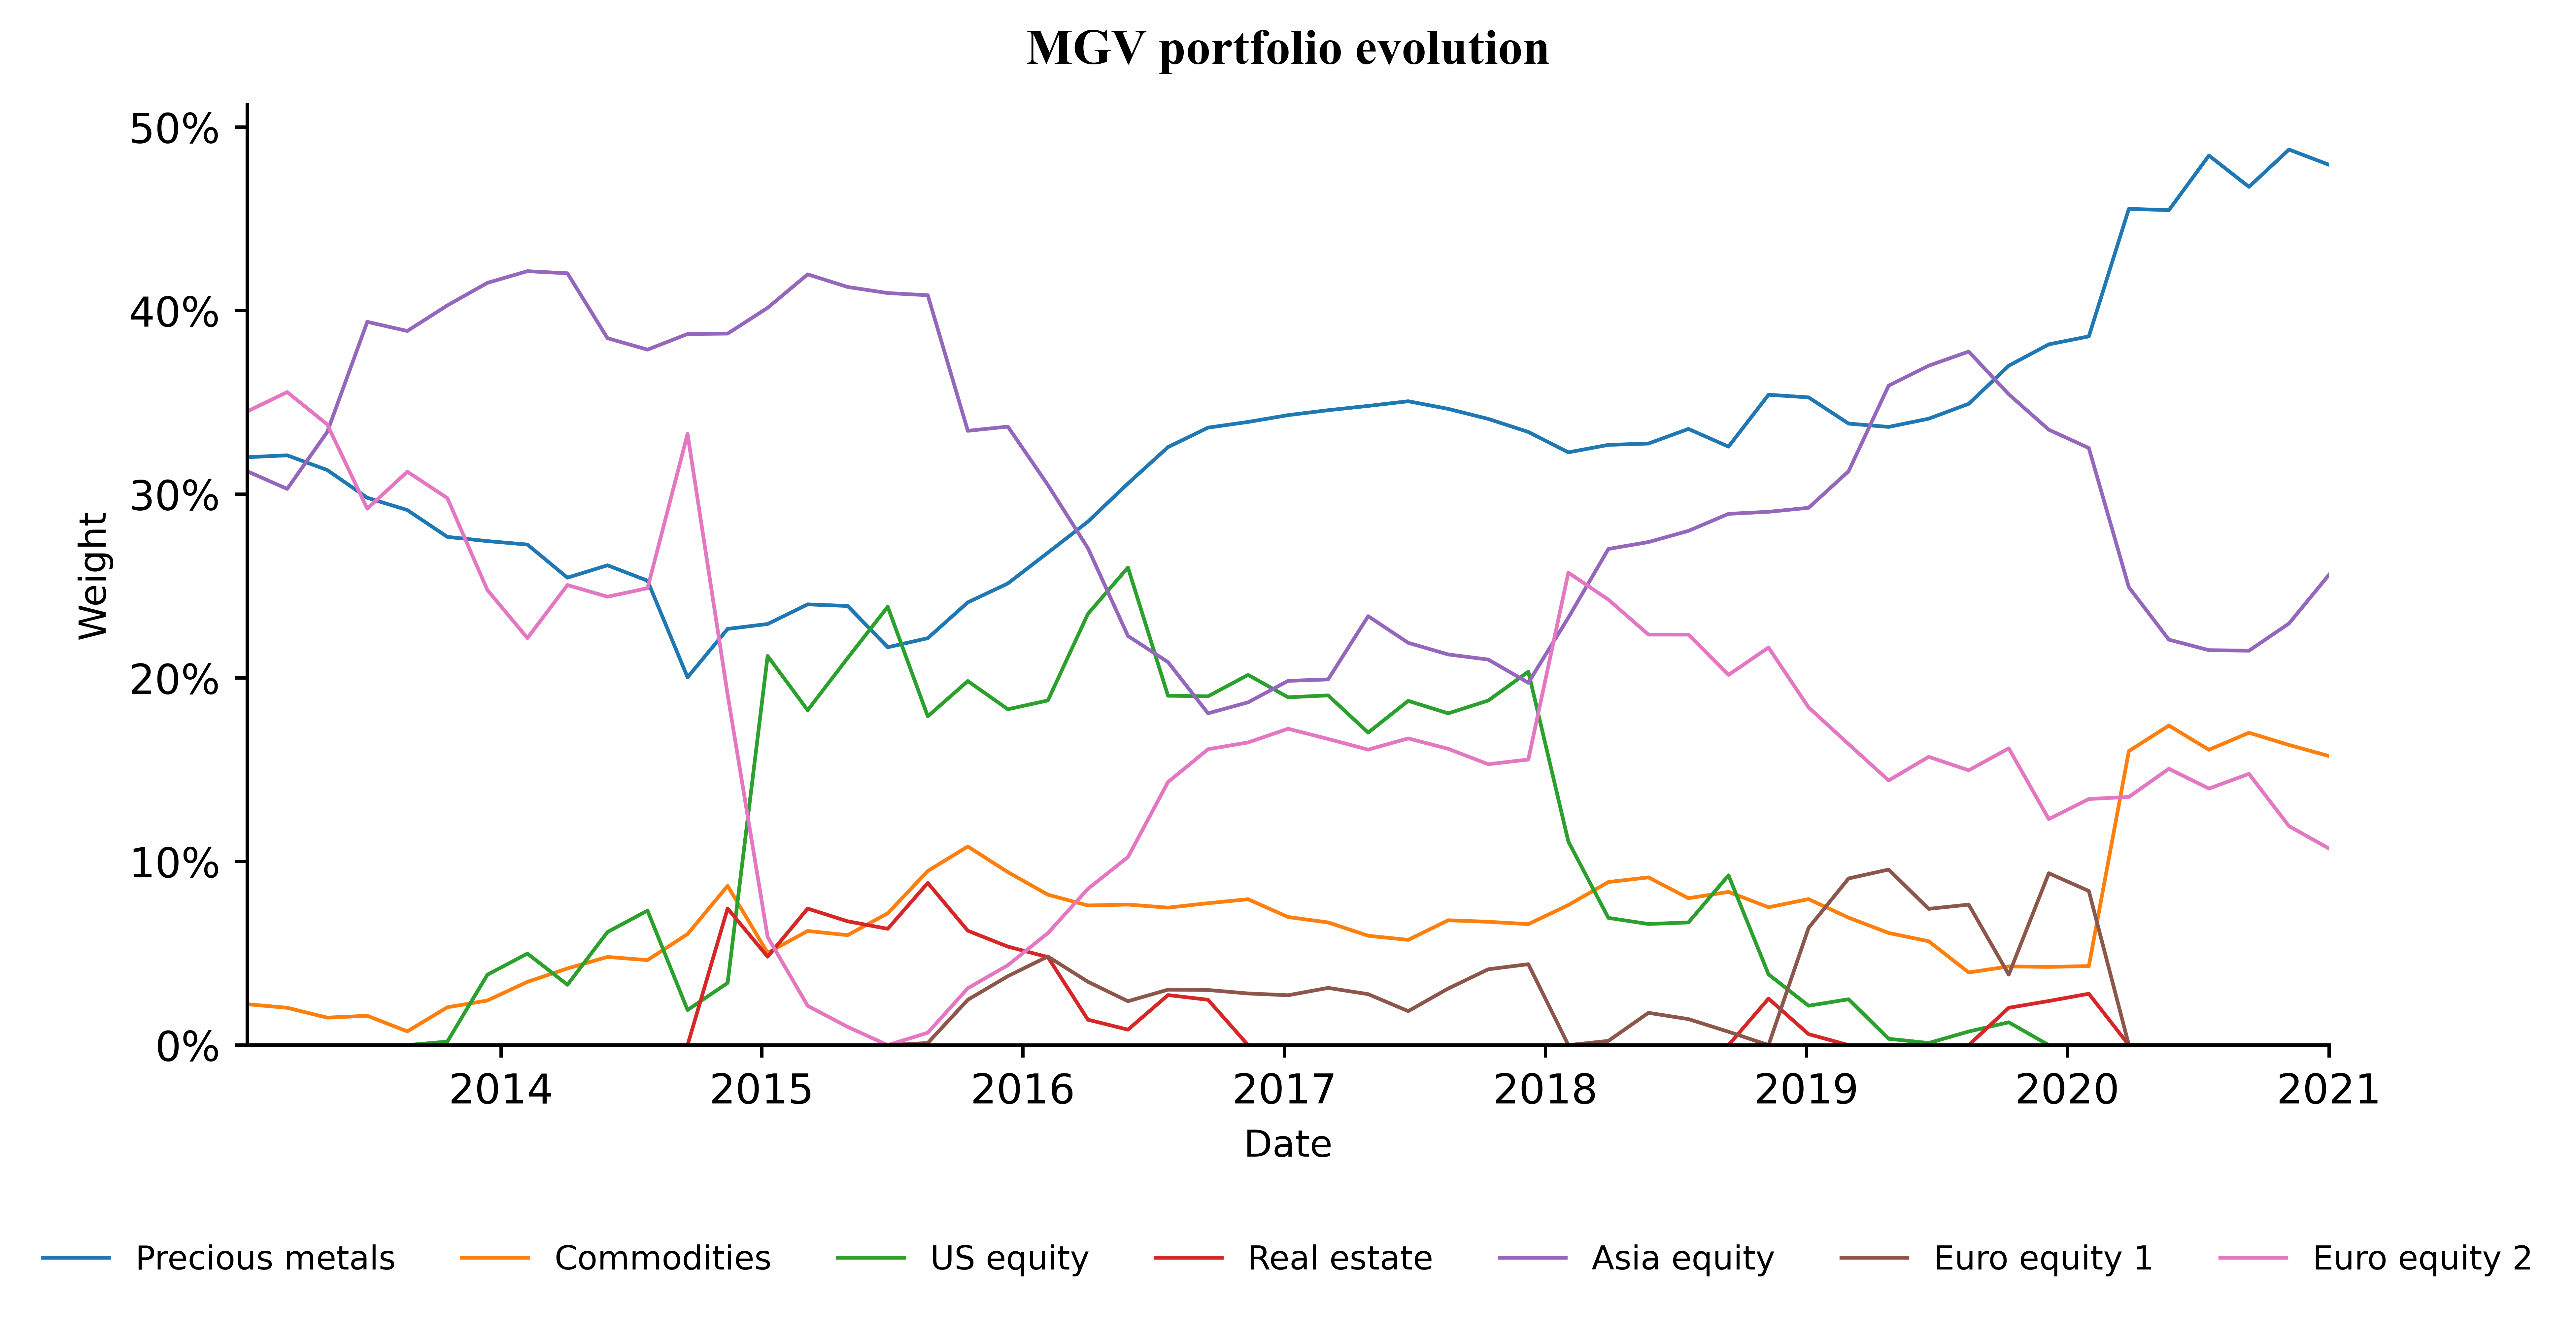

In [31]:
# ────────────────────────────────── MGV grouped weights over time ──────────────────────────────────
fig, ax = plt.subplots(num=13, dpi=900, figsize=(cm_inch(20), cm_inch(12)))

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(colors="#666666", length=3)

# Plot only groups present in this run (bonds column absent if not in analysis)
for group, series in grouped_weights["MGV"].items():
    ax.plot(dates_rebalance, series, label=group, lw=0.9)

ax.set_title("MGV portfolio evolution", fontdict=FONT, loc="center", pad=10)
ax.set_xlabel("Date", fontsize=9, color="#666666")
ax.set_ylabel("Weight", fontsize=9, color="#666666")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.tick_params(colors="black", length=3)
ax.set_xlabel("Date", fontsize=9, color="black")
ax.set_ylabel("Weight", fontsize=9, color="black")

ax.xaxis.label.set_color("black")
ax.yaxis.label.set_color("black")
plt.setp(ax.get_xticklabels(), color="black")
plt.setp(ax.get_yticklabels(), color="black")

ax.legend(
    frameon=False,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),   # below the x-axis label
    ncol=len(grouped_weights["HRP"].columns),
)

ax.set_xlim(dates_rebalance.iloc[0], dates_rebalance.iloc[-1])
ax.set_ylim(bottom=0)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.10))

plt.tight_layout()
plt.subplots_adjust(bottom=0.25, left=0.08, right=0.97, top=0.92)
plt.show()

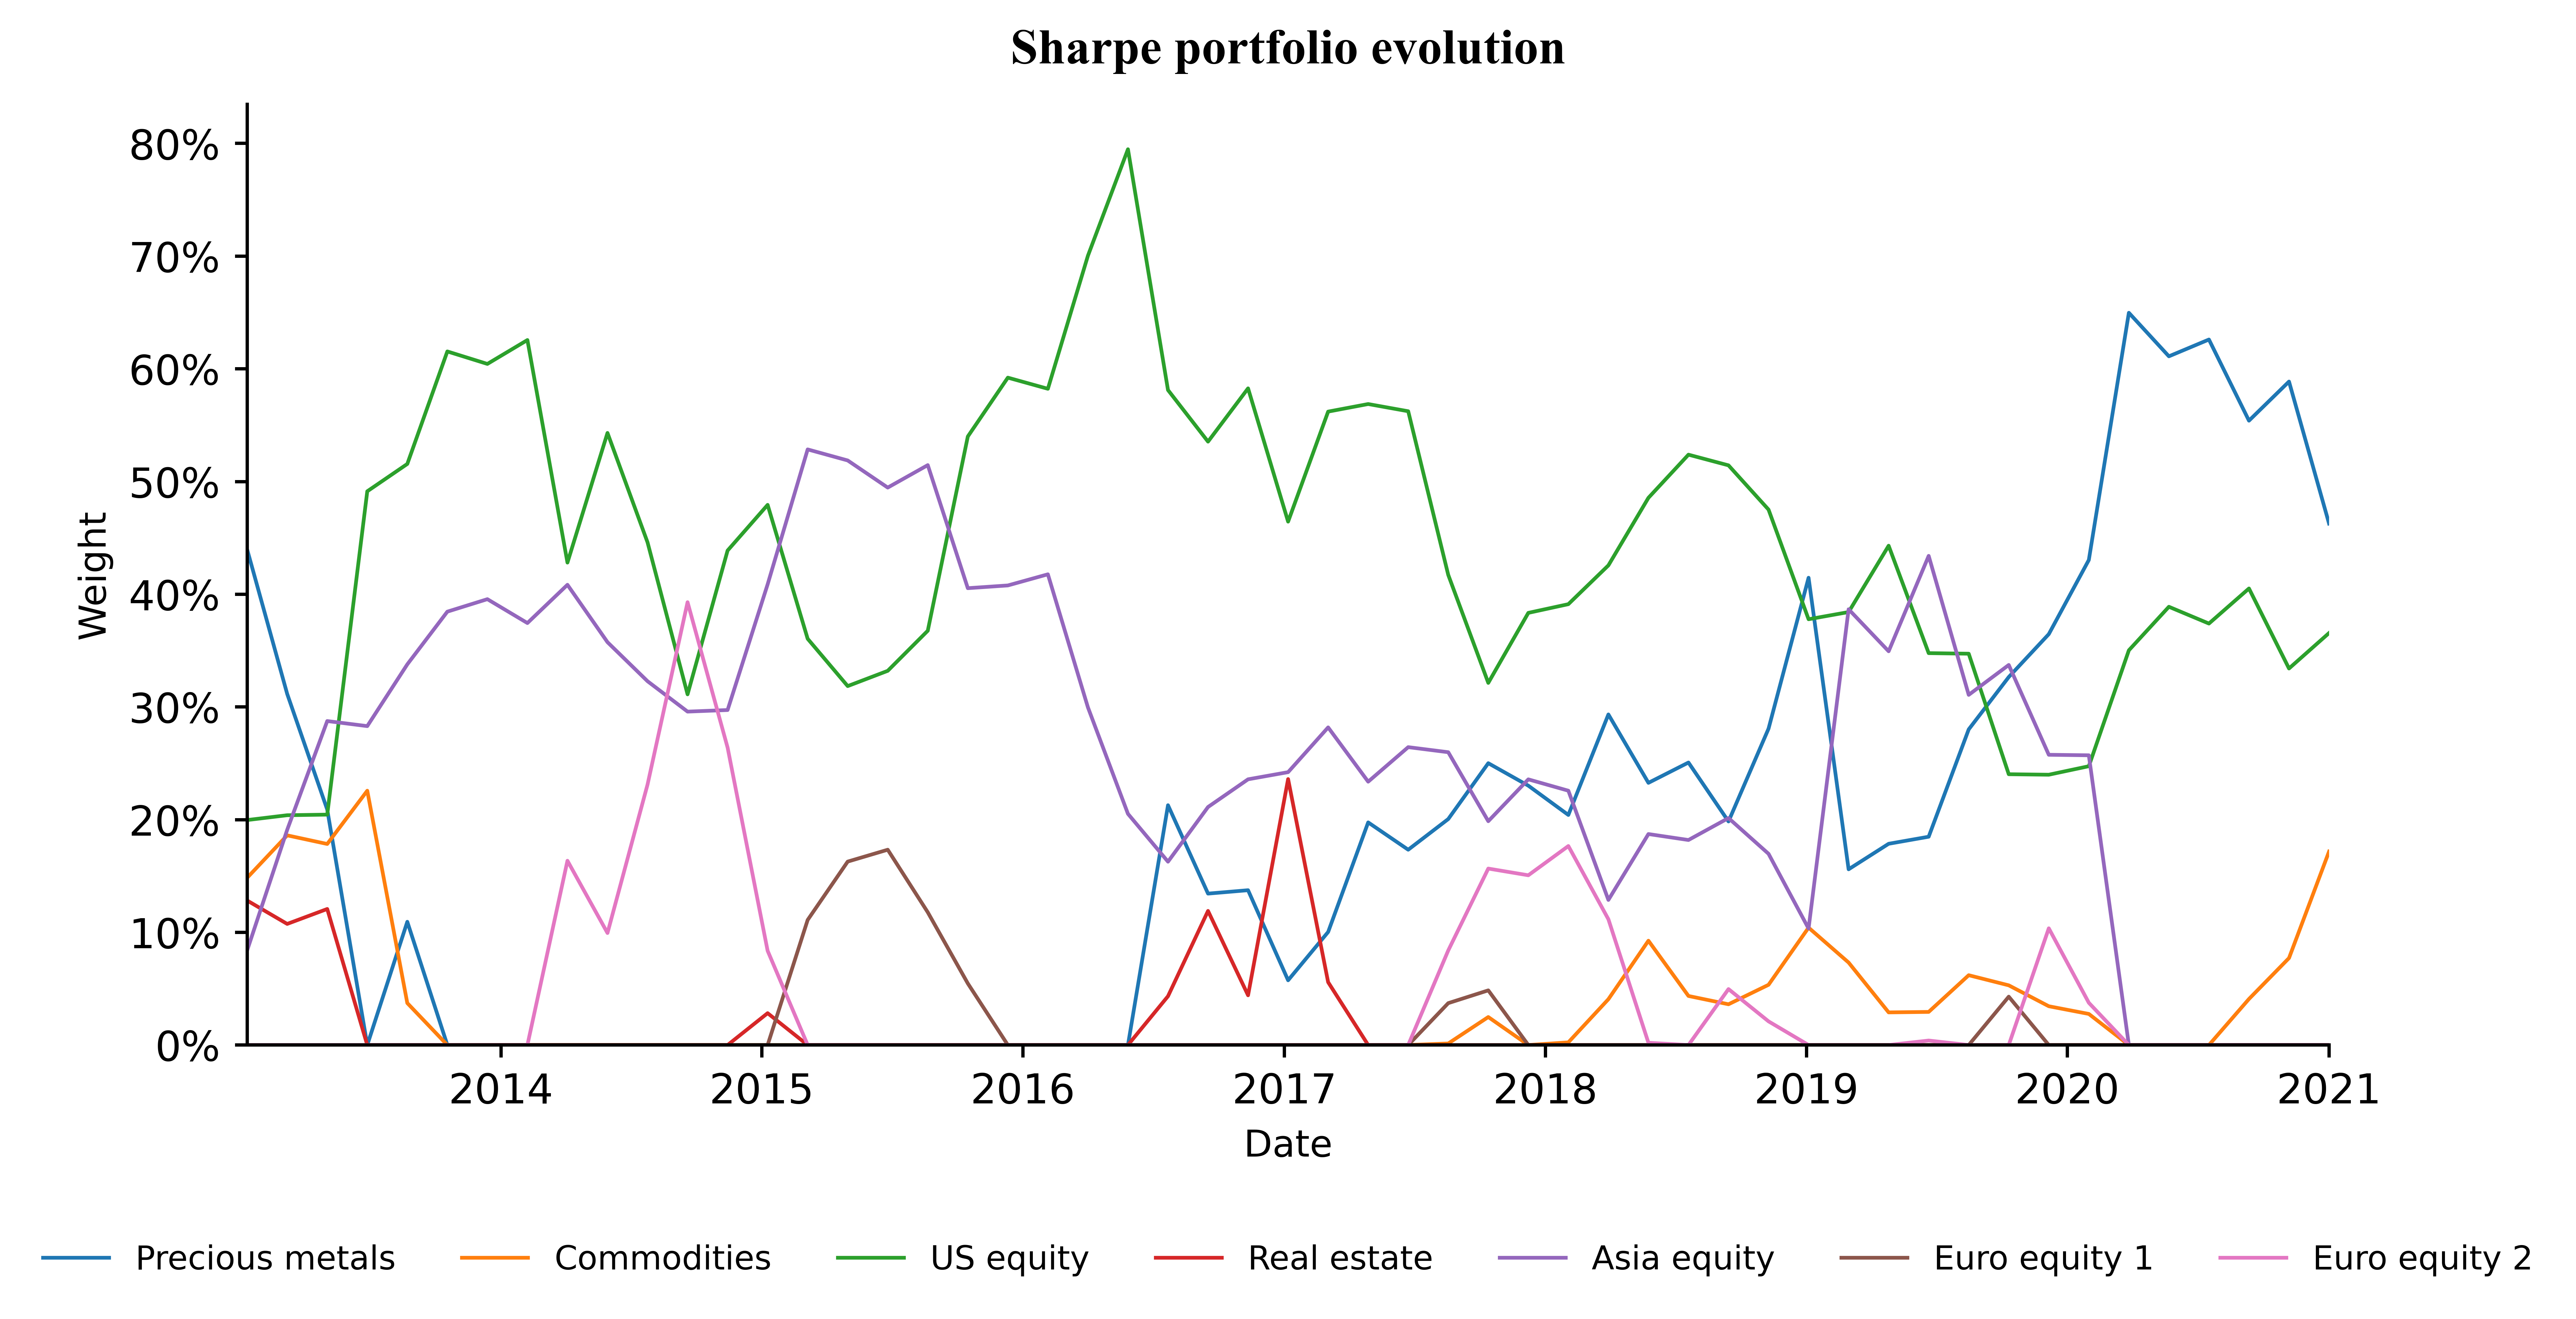

In [32]:
# ────────────────────────────────── Sharpe grouped weights over time ──────────────────────────────────
fig, ax = plt.subplots(num=13, dpi=900, figsize=(cm_inch(20), cm_inch(12)))

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(colors="#666666", length=3)

# Plot only groups present in this run (bonds column absent if not in analysis)
for group, series in grouped_weights["Sharpe"].items():
    ax.plot(dates_rebalance, series, label=group, lw=0.9)

ax.set_title("Sharpe portfolio evolution", fontdict=FONT, loc="center", pad=10)
ax.set_xlabel("Date", fontsize=9, color="#666666")
ax.set_ylabel("Weight", fontsize=9, color="#666666")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.tick_params(colors="black", length=3)
ax.set_xlabel("Date", fontsize=9, color="black")
ax.set_ylabel("Weight", fontsize=9, color="black")

ax.xaxis.label.set_color("black")
ax.yaxis.label.set_color("black")
plt.setp(ax.get_xticklabels(), color="black")
plt.setp(ax.get_yticklabels(), color="black")

ax.legend(
    frameon=False,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),   # below the x-axis label
    ncol=len(grouped_weights["HRP"].columns),
)

ax.set_xlim(dates_rebalance.iloc[0], dates_rebalance.iloc[-1])
ax.set_ylim(bottom=0)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.10))

plt.tight_layout()
plt.subplots_adjust(bottom=0.25, left=0.08, right=0.97, top=0.92)
plt.show()